# Graficas Test 2 ($S_n$) + comparativas con Pyomo q=1

Este notebook replica el flujo de `04_plots_test2.ipynb` y agrega una capa de comparacion con los resultados de Pyomo, incluyendo `q=1`.

La idea es trabajar con dos vistas:

- **Resultados clasicos**: `argmin`, `median`, `trimmed` desde `sn_simulation_*.csv`.
- **Resultados Pyomo**: `argmin_pyomo`, cargando `sn_pyomo_q1_*.csv` y `sn_pyomo_simulation_*.csv` cuando existan.

Nota: si solo existen archivos `_quick`, las comparaciones Pyomo son diagnosticas y no deben leerse como conclusiones finales de potencia o nivel.

In [21]:
# --- Setup ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from src.plotting_sn import (
    plot_type_i_error_sn, plot_power_curves_sn, plot_runtime_sn,
    plot_q1_vs_q2, plot_weights_compare, plot_power_heatmap,
    plot_pvalue_distribution_h0_sn,
    plot_tn_vs_sn_power, plot_tn_vs_sn_runtime,
)

DATA_DIR = ROOT / 'results' / 'data'
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

alpha = 0.05
print(f'Working dir: {Path.cwd()}')

Working dir: c:\Users\juanc\github\Proyecto2EstadisticaNP


## Cargar CSVs

`use_quick_classic` controla los datos clasicos. Para Pyomo el notebook intenta cargar primero los archivos completos y, si no existen, cae a los `_quick`.

In [22]:
use_quick_classic = False
classic_suffix = '_quick' if use_quick_classic else ''

classic_raw_csv = DATA_DIR / f'sn_simulation_raw{classic_suffix}.csv'
classic_sum_csv = DATA_DIR / f'sn_simulation_summary{classic_suffix}.csv'

if not classic_raw_csv.exists() or not classic_sum_csv.exists():
    raise FileNotFoundError(
        f'No se encontraron {classic_raw_csv.name} / {classic_sum_csv.name}. '
        'Ejecuta primero notebooks/02_run_test2.ipynb.'
    )

df_classic = pd.read_csv(classic_raw_csv)
summary_classic = pd.read_csv(classic_sum_csv)
df_classic['source'] = 'clasico'
summary_classic['source'] = 'clasico'

print(f'Clasico: {classic_raw_csv.name} ({len(df_classic):,} filas) / {classic_sum_csv.name} ({len(summary_classic)} filas)')
print(f"q: {sorted(df_classic.q.unique())}, pesos: {sorted(df_classic.weight.unique())}")
print(f"n: {sorted(df_classic.n.unique())}, estimadores: {sorted(df_classic.estimator.unique())}")

tn_sum_csv = DATA_DIR / 'tn_simulation_summary.csv'
summary_tn = pd.read_csv(tn_sum_csv) if tn_sum_csv.exists() else None
if summary_tn is not None:
    print(f'\nT_n: {tn_sum_csv.name} ({len(summary_tn)} filas) - comparativas disponibles')
else:
    print(f'\n(no se encontro {tn_sum_csv.name} - saltando comparativas T_n vs S_n)')

Clasico: sn_simulation_raw.csv (72,000 filas) / sn_simulation_summary.csv (360 filas)
q: [np.int64(1), np.int64(2)], pesos: ['gauss_0.5', 'gauss_1.0', 'laplace_1.0']
n: [np.int64(20), np.int64(40), np.int64(80), np.int64(160)], estimadores: ['argmin', 'median', 'trimmed']

T_n: tn_simulation_summary.csv (60 filas) - comparativas disponibles


In [23]:
def read_first_existing(candidates, label):
    for path in candidates:
        if path.exists():
            return pd.read_csv(path), path
    print(f'(!) No se encontro ningun CSV para {label}:')
    for path in candidates:
        print(f'    - {path.name}')
    return None, None

pyomo_q1_sum, pyomo_q1_sum_path = read_first_existing(
    [DATA_DIR / 'sn_pyomo_q1_summary.csv', DATA_DIR / 'sn_pyomo_q1_summary_quick.csv'],
    'Pyomo q=1 summary',
)
pyomo_q1_raw, pyomo_q1_raw_path = read_first_existing(
    [DATA_DIR / 'sn_pyomo_q1_raw.csv', DATA_DIR / 'sn_pyomo_q1_raw_quick.csv'],
    'Pyomo q=1 raw',
)
pyomo_q2_sum, pyomo_q2_sum_path = read_first_existing(
    [DATA_DIR / 'sn_pyomo_simulation_summary.csv', DATA_DIR / 'sn_pyomo_simulation_summary_quick.csv'],
    'Pyomo q=2 summary',
)
pyomo_q2_raw, pyomo_q2_raw_path = read_first_existing(
    [DATA_DIR / 'sn_pyomo_simulation_raw.csv', DATA_DIR / 'sn_pyomo_simulation_raw_quick.csv'],
    'Pyomo q=2 raw',
)

pyomo_summary_parts = []
pyomo_raw_parts = []
for df, path, label in [
    (pyomo_q1_sum, pyomo_q1_sum_path, 'pyomo_q1'),
    (pyomo_q2_sum, pyomo_q2_sum_path, 'pyomo_q2'),
]:
    if df is not None:
        df = df.copy()
        df['source'] = 'pyomo'
        df['file_source'] = path.name
        pyomo_summary_parts.append(df)
        print(f'{label}: {path.name} ({len(df)} filas)')

for df, path, label in [
    (pyomo_q1_raw, pyomo_q1_raw_path, 'pyomo_q1 raw'),
    (pyomo_q2_raw, pyomo_q2_raw_path, 'pyomo_q2 raw'),
]:
    if df is not None:
        df = df.copy()
        df['source'] = 'pyomo'
        df['file_source'] = path.name
        pyomo_raw_parts.append(df)

summary_pyomo = pd.concat(pyomo_summary_parts, ignore_index=True) if pyomo_summary_parts else pd.DataFrame()
df_pyomo = pd.concat(pyomo_raw_parts, ignore_index=True) if pyomo_raw_parts else pd.DataFrame()

if not summary_pyomo.empty:
    display(summary_pyomo[['file_source', 'dist', 'under_h0', 'n', 'estimator', 'q', 'weight', 'reject_rate', 'mean_time_s', 'n_rep']])
else:
    display(Markdown('**No hay resultados Pyomo cargados.**'))

pyomo_q1: sn_pyomo_q1_summary_quick.csv (3 filas)
pyomo_q2: sn_pyomo_simulation_summary_quick.csv (10 filas)


,file_source,dist,under_h0,n,estimator,q,weight,reject_rate,mean_time_s,n_rep
0,sn_pyomo_q1_summary_quick.csv,"Cauchy(loc=2.0,scale=1.0)",True,20,argmin_pyomo,1,gauss_1.0,0.0,0.398823,3
1,sn_pyomo_q1_summary_quick.csv,"Gamma(k=2.0,s=1.0)",False,20,argmin_pyomo,1,gauss_1.0,0.0,0.153050,3
2,sn_pyomo_q1_summary_quick.csv,"Uniforme(1.0,3.0)",True,20,argmin_pyomo,1,gauss_1.0,0.0,0.891780,3
3,sn_pyomo_simulation_summary_quick.csv,"Cauchy(loc=2.0,scale=1.0)",True,20,argmin_pyomo,2,gauss_1.0,0.0,0.822737,10
4,sn_pyomo_simulation_summary_quick.csv,"Cauchy(loc=2.0,scale=1.0)",True,40,argmin_pyomo,2,gauss_1.0,0.0,0.915984,10
5,sn_pyomo_simulation_summary_quick.csv,"Gamma(k=2.0,s=1.0)",False,20,argmin_pyomo,2,gauss_1.0,0.3,0.855862,10
6,sn_pyomo_simulation_summary_quick.csv,"Gamma(k=2.0,s=1.0)",False,40,argmin_pyomo,2,gauss_1.0,0.2,0.770792,10
7,sn_pyomo_simulation_summary_quick.csv,"Pareto(a=3.0,s=1.0)",False,20,argmin_pyomo,2,gauss_1.0,0.0,0.837390,10
8,sn_pyomo_simulation_summary_quick.csv,"Pareto(a=3.0,s=1.0)",False,40,argmin_pyomo,2,gauss_1.0,0.1,0.697320,10
9,sn_pyomo_simulation_summary_quick.csv,"Uniforme(1.0,3.0)",True,20,argmin_pyomo,2,gauss_1.0,0.0,2.432679,10


## Dataset combinado para comparar todos

In [24]:
def normalize_summary(df):
    out = df.copy()
    bool_map = {'True': True, 'False': False, True: True, False: False}
    out['under_h0'] = out['under_h0'].map(bool_map).fillna(out['under_h0']).astype(bool)
    for col in ['n', 'q', 'n_rep']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce').astype('Int64')
    for col in ['reject_rate', 'mean_pvalue', 'mean_stat', 'mean_time_s', 'sd_time_s', 'se_rate']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out

summary_all = pd.concat([summary_classic, summary_pyomo], ignore_index=True, sort=False)
summary_all = normalize_summary(summary_all)
summary_all['method'] = np.where(
    summary_all['source'].eq('pyomo'),
    'pyomo | ' + summary_all['estimator'].astype(str),
    'clasico | ' + summary_all['estimator'].astype(str),
)
summary_all['config'] = (
    summary_all['method'] + ' | q=' + summary_all['q'].astype(str)
    + ' | ' + summary_all['weight'].astype(str)
)

raw_parts = [df_classic]
if not df_pyomo.empty:
    raw_parts.append(df_pyomo)
df_all = pd.concat(raw_parts, ignore_index=True, sort=False)
df_all['method'] = np.where(
    df_all['source'].eq('pyomo'),
    'pyomo | ' + df_all['estimator'].astype(str),
    'clasico | ' + df_all['estimator'].astype(str),
)

print(f'Summary combinado: {len(summary_all)} filas')
display(summary_all.pivot_table(index=['source', 'estimator', 'q', 'weight'], columns='n', values='n_rep', aggfunc='max'))

min_rep_pyomo = summary_pyomo['n_rep'].min() if not summary_pyomo.empty and 'n_rep' in summary_pyomo else None
if min_rep_pyomo is not None and min_rep_pyomo < 30:
    display(Markdown(f'**Aviso:** hay resultados Pyomo con `n_rep={int(min_rep_pyomo)}`. Usarlos solo como smoke test / diagnostico.'))

Summary combinado: 373 filas


n                                   20    40    80    160
source  estimator    q weight                            
clasico argmin       1 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
                     2 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
        median       1 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
                     2 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
        trimmed      1 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
                     2 gauss_0.5    200   200   200   200
                       gauss_1.0    200   200   200   200
                       laplace_1.0  200   200   200   200
pyomo   argmin_pyomo 1 gauss_1.0      3  <NA>  <NA>  <NA>
                     2 gauss_1.0     10    10  <NA>  <NA>

**Aviso:** hay resultados Pyomo con `n_rep=3`. Usarlos solo como smoke test / diagnostico.

## Resumen pivotado clasico

In [25]:
print('Tasa de rechazo (argmin, q=2, columnas = peso):')
sub = summary_classic[(summary_classic['estimator'] == 'argmin') & (summary_classic['q'] == 2)]
if not sub.empty:
    display(sub.pivot_table(index=['dist', 'n'], columns='weight', values='reject_rate').round(3))

print('\nTiempo medio por test (s), por estimador y q (promedio sobre pesos):')
display(summary_classic.pivot_table(index=['estimator', 'n'], columns='q', values='mean_time_s').round(3))

Tasa de rechazo (argmin, q=2, columnas = peso):


weight                         gauss_0.5  gauss_1.0  laplace_1.0
dist                      n                                     
Cauchy(loc=2.0,scale=1.0) 20       0.010      0.005        0.000
                          40       0.020      0.015        0.005
                          80       0.030      0.010        0.020
                          160      0.065      0.050        0.010
Gamma(k=2.0,s=1.0)        20       0.140      0.175        0.150
                          40       0.530      0.475        0.260
                          80       0.980      0.785        0.485
                          160      1.000      0.975        0.785
Pareto(a=3.0,s=1.0)       20       0.245      0.240        0.205
                          40       0.310      0.425        0.795
                          80       0.525      0.925        1.000
                          160      0.950      1.000        1.000
Uniforme(1.0,3.0)         20       0.025      0.040        0.055
                          40       0.055      0.050        0.055
                          80       0.035      0.055        0.040
                          160      0.060      0.035        0.010
Weibull(k=1.5,s=1.0)      20       0.190      0.115        0.100
                          40       0.370      0.540        0.325
                          80       0.855      0.925        0.655
                          160      0.985      1.000        0.935


Tiempo medio por test (s), por estimador y q (promedio sobre pesos):


q                   1      2
estimator n                 
argmin    20    2.692  0.272
          40    3.992  0.304
          80    6.745  0.417
          160  12.293  0.630
median    20    0.057  0.056
          40    0.101  0.104
          80    0.196  0.204
          160   0.394  0.411
trimmed   20    0.058  0.058
          40    0.102  0.105
          80    0.197  0.198
          160   0.400  0.415

# Figuras originales de `04_plots_test2`

In [26]:
def show(path):
    if path is not None and Path(path).exists():
        display(Image(filename=str(path)))
    else:
        print('(sin imagen)')

def show_many(paths):
    for path in paths:
        show(path)

### Error Tipo I bajo $H_0$ (clasico)

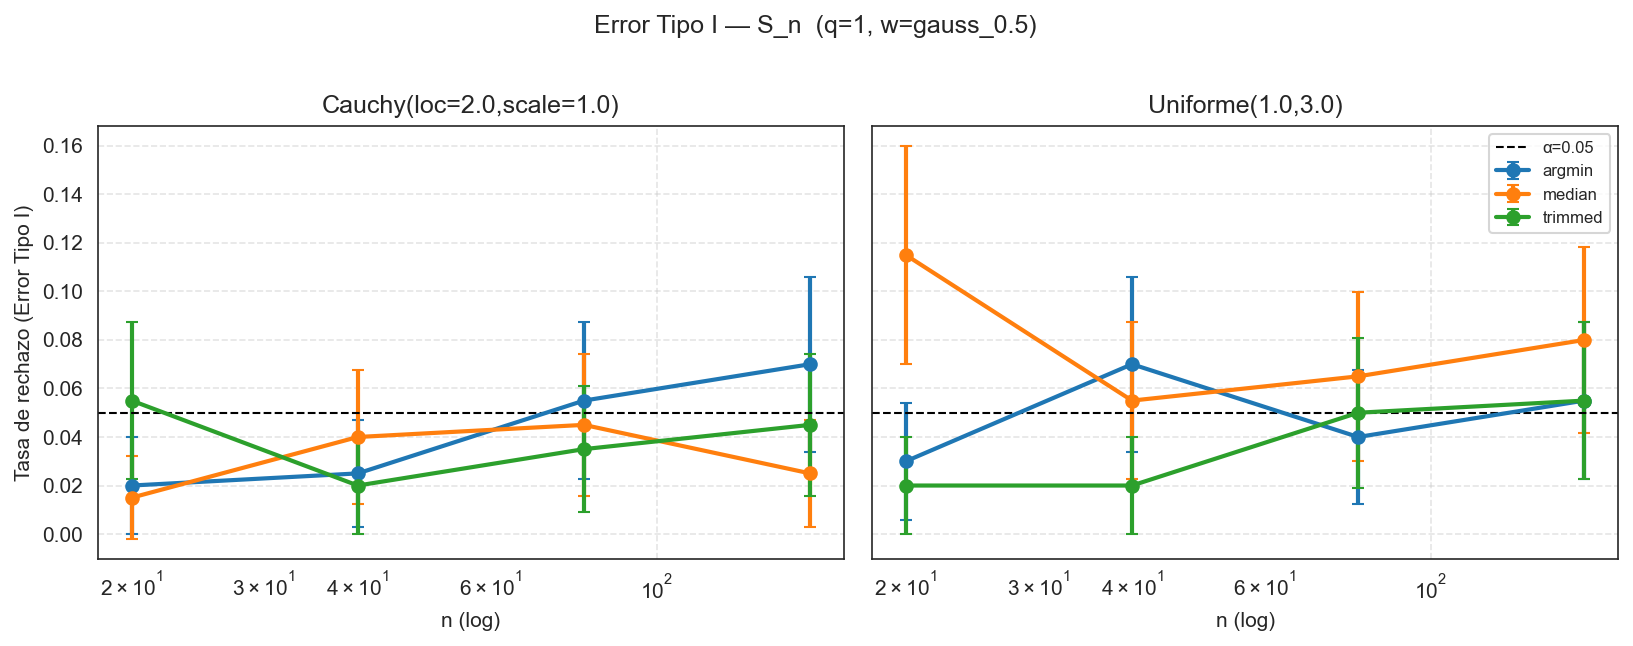

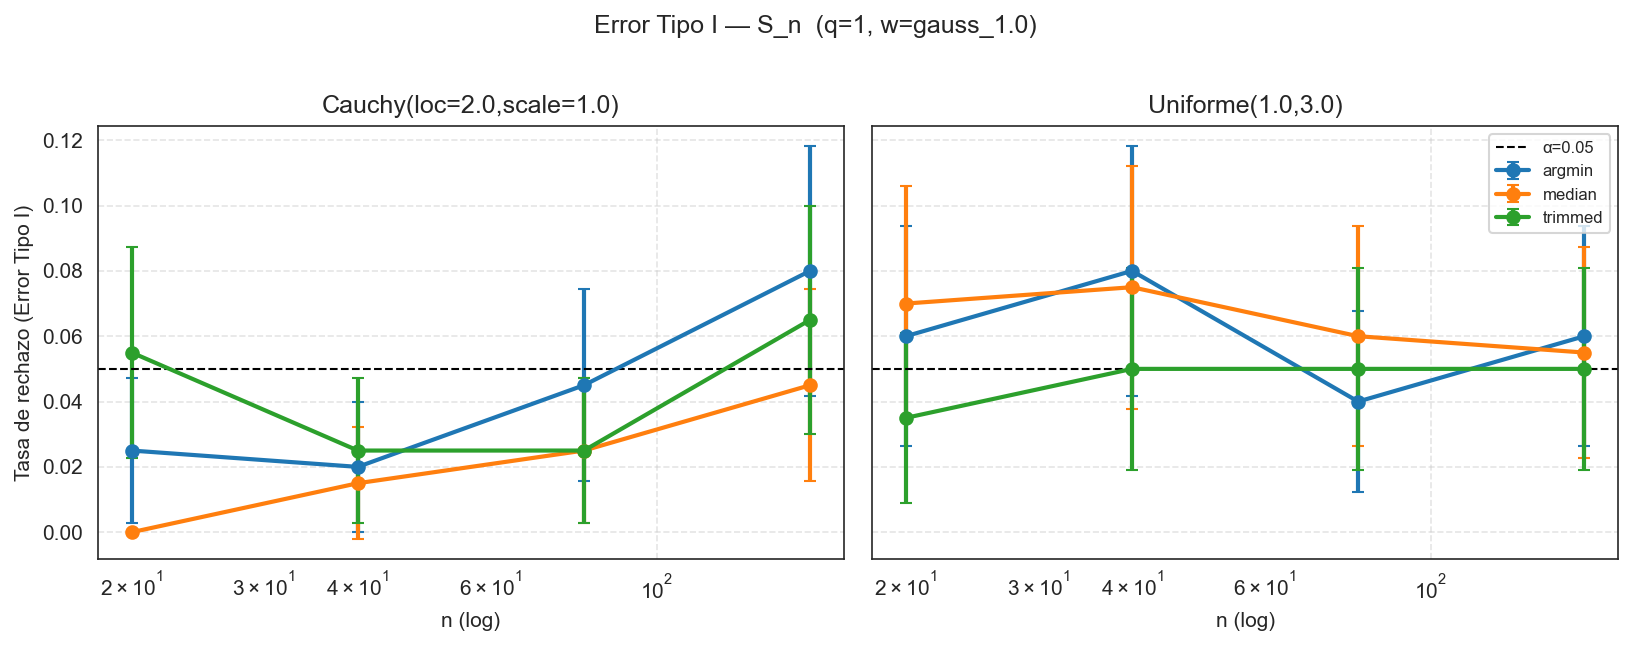

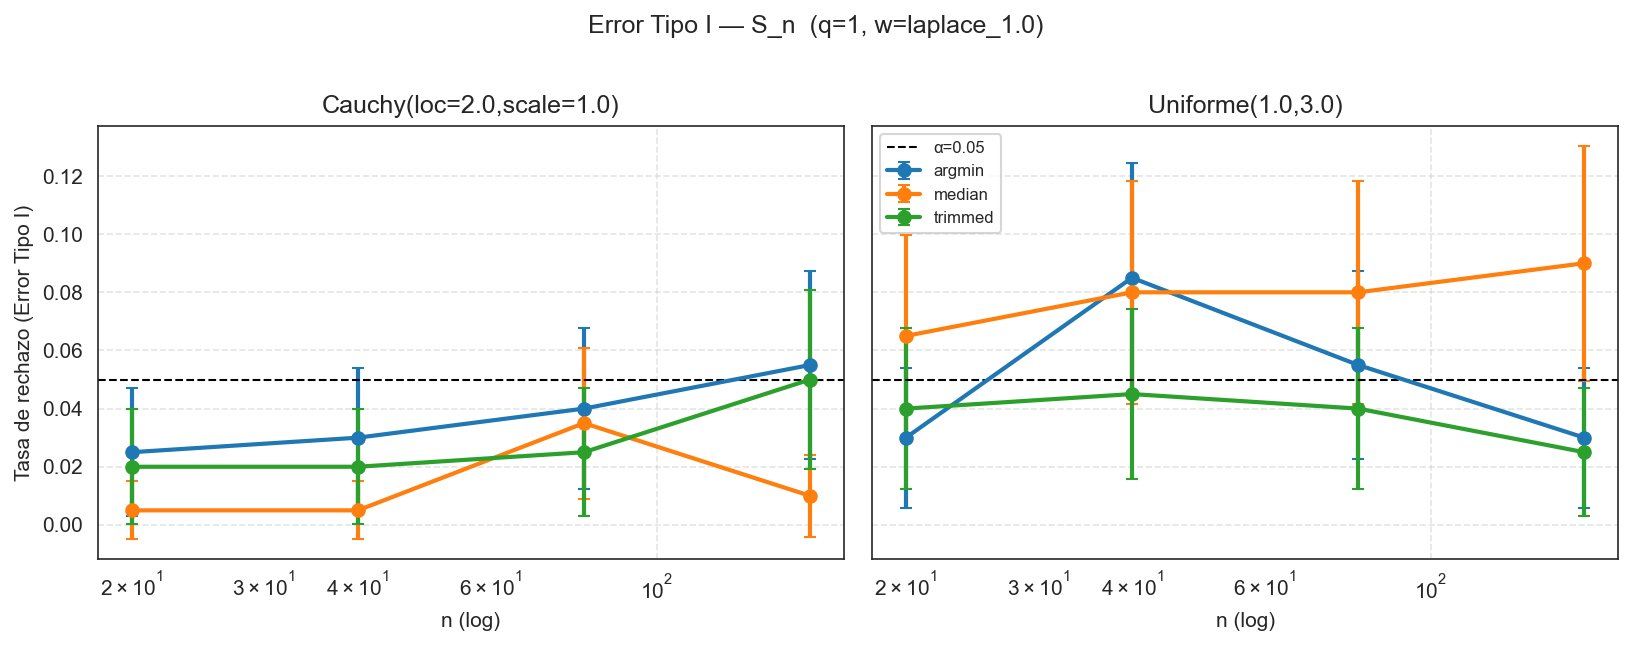

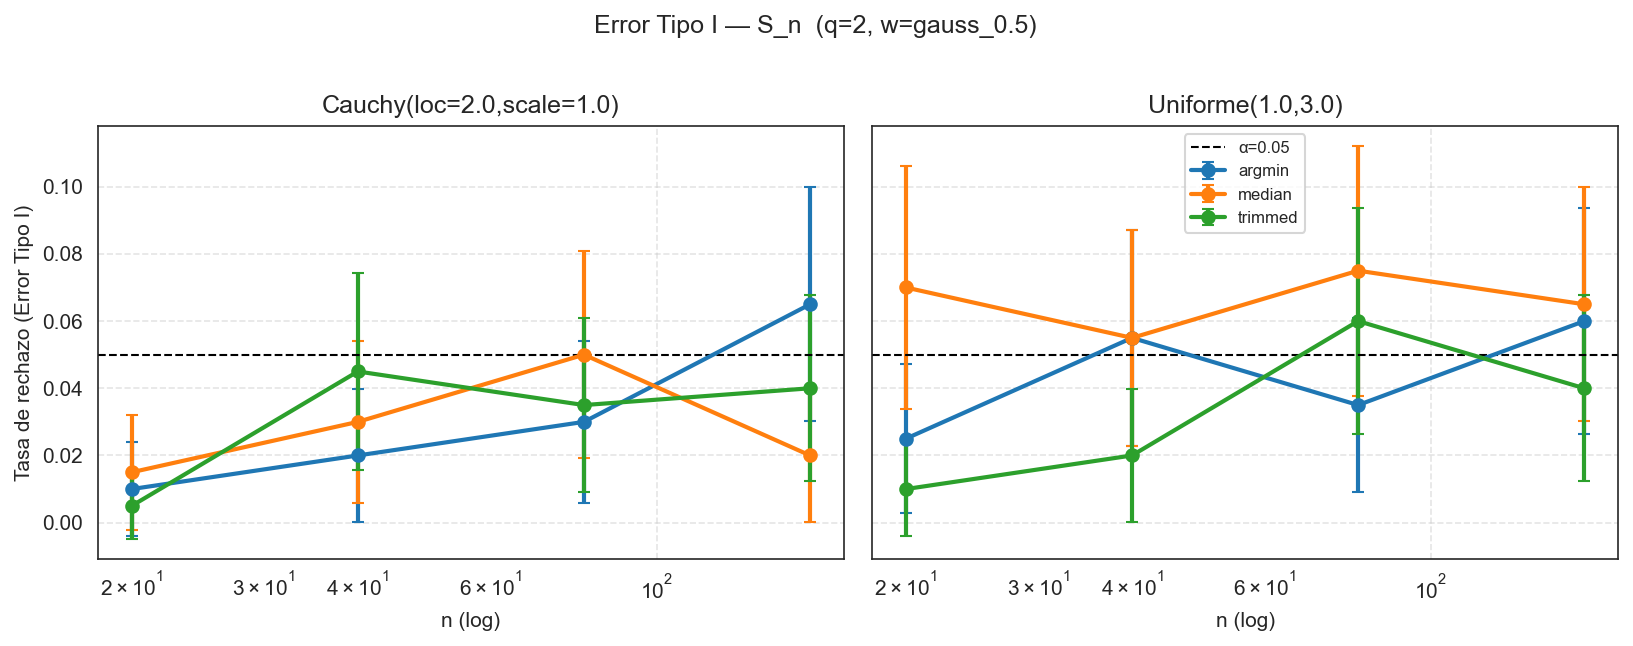

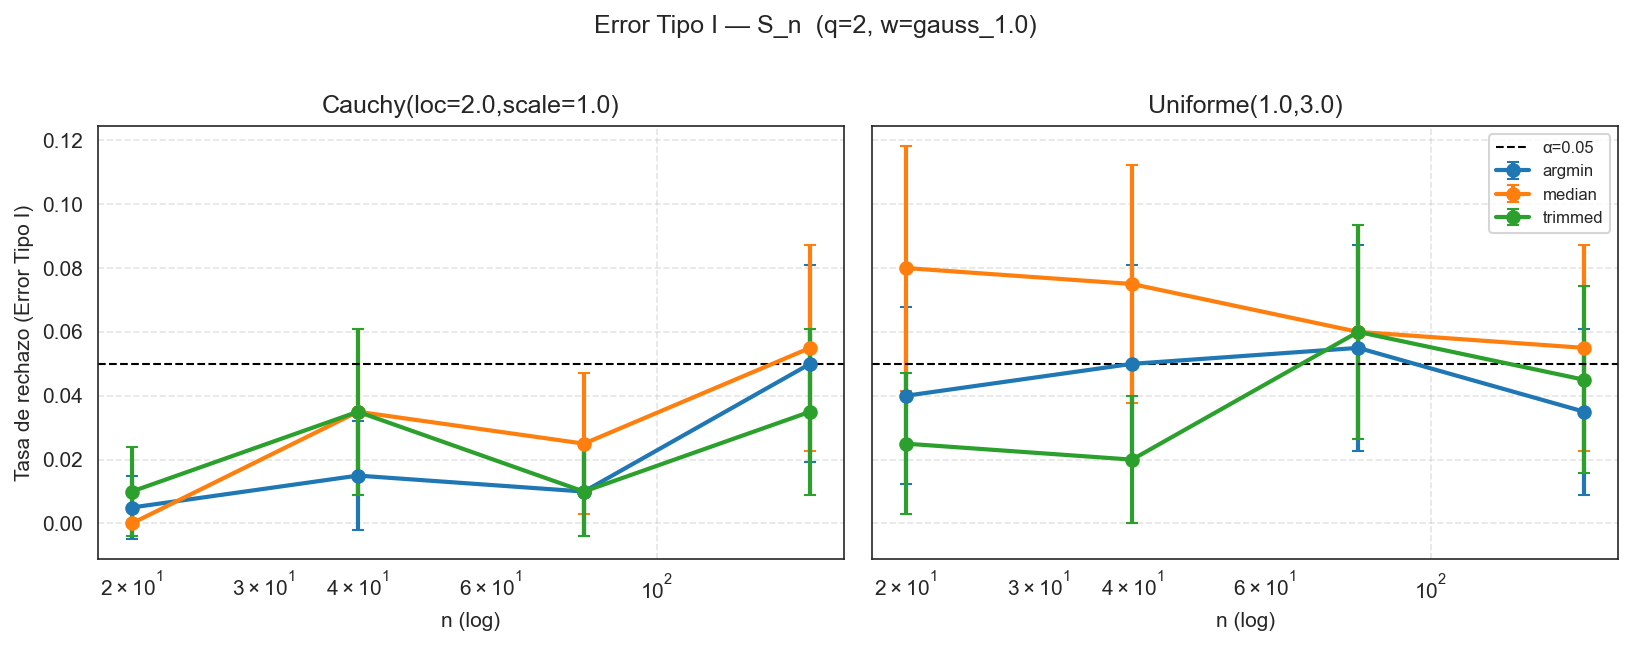

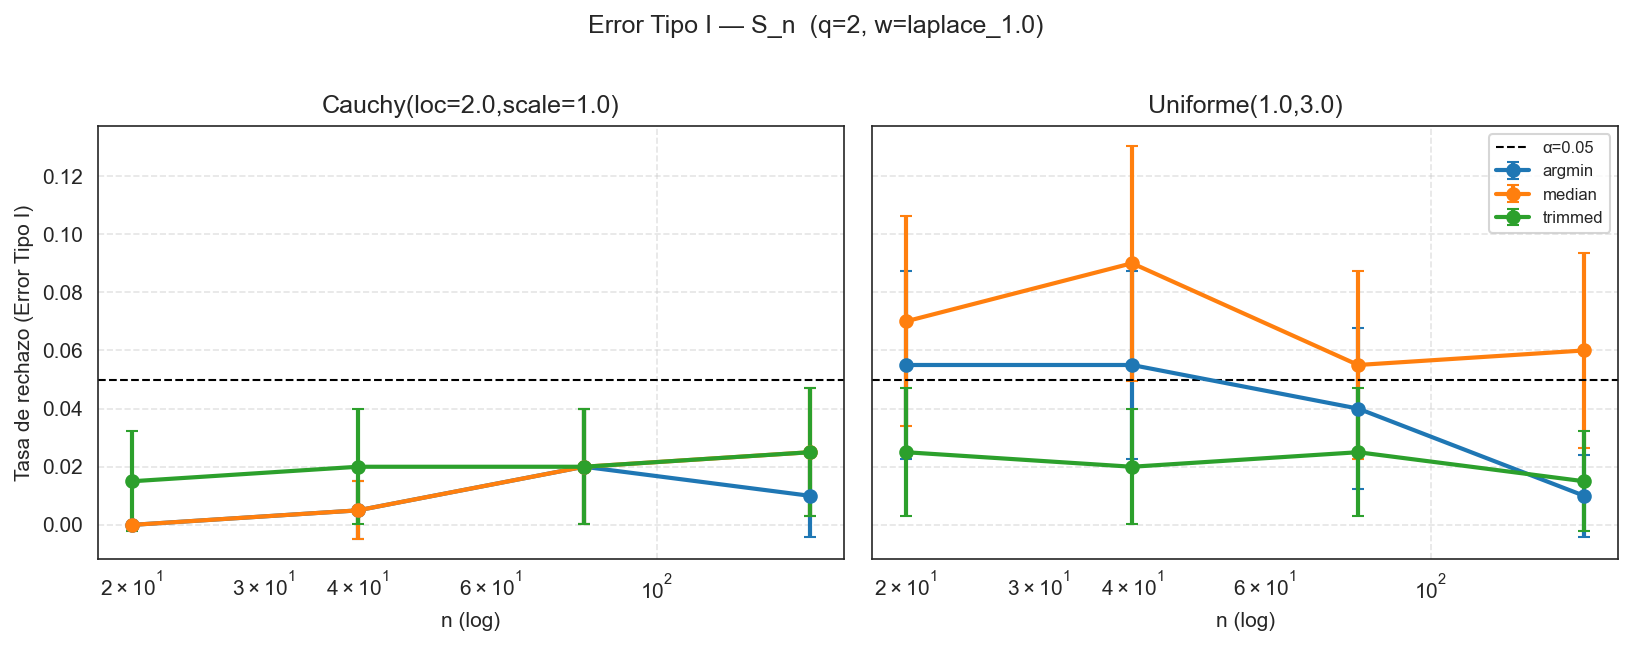

In [27]:
show_many(plot_type_i_error_sn(summary_classic, alpha=alpha, outdir=FIG_DIR))

### Curvas de potencia bajo $H_a$ (clasico)

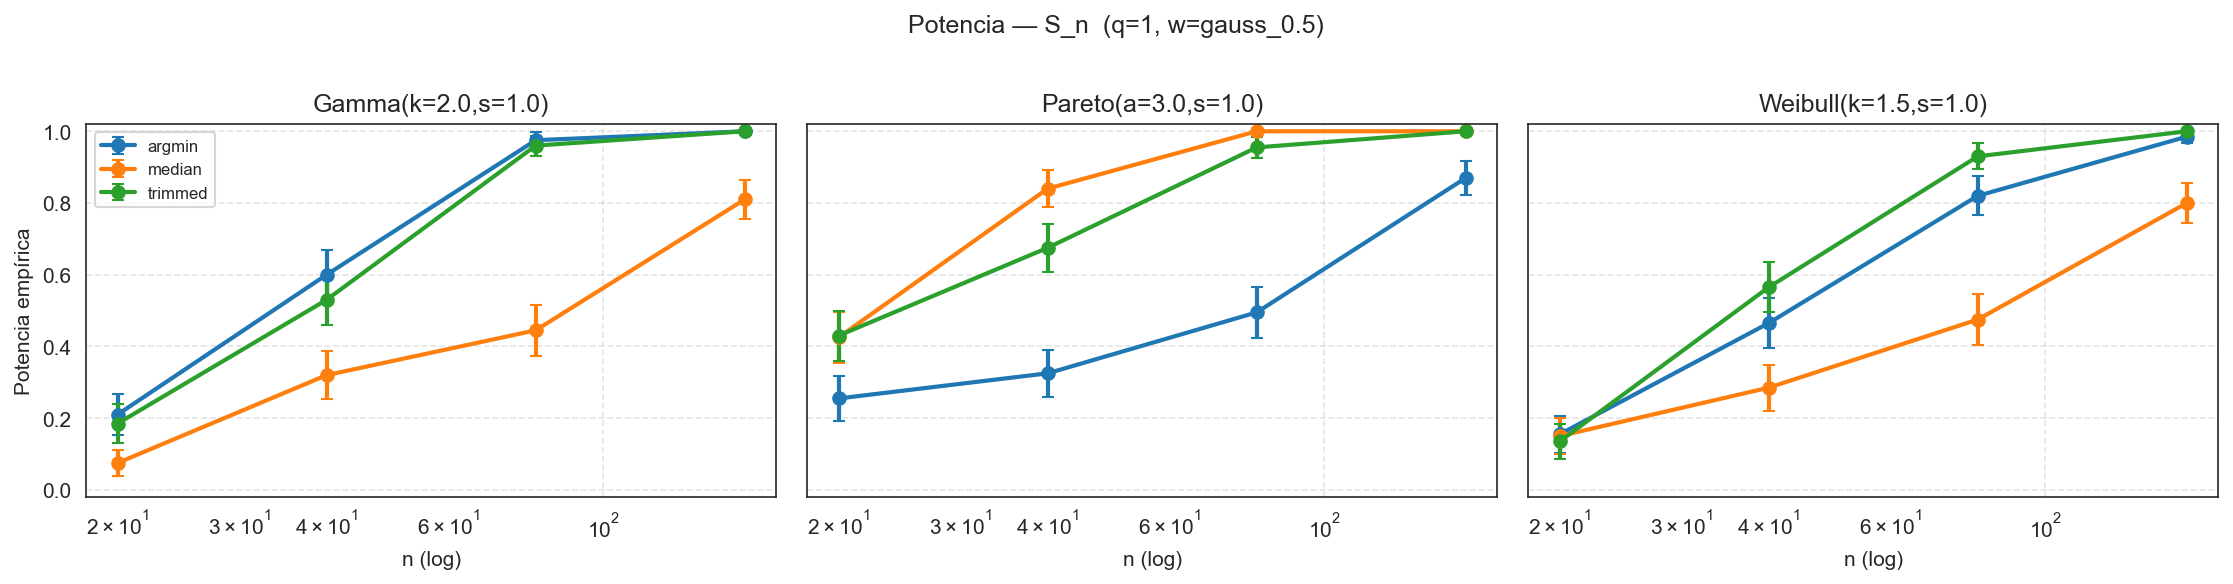

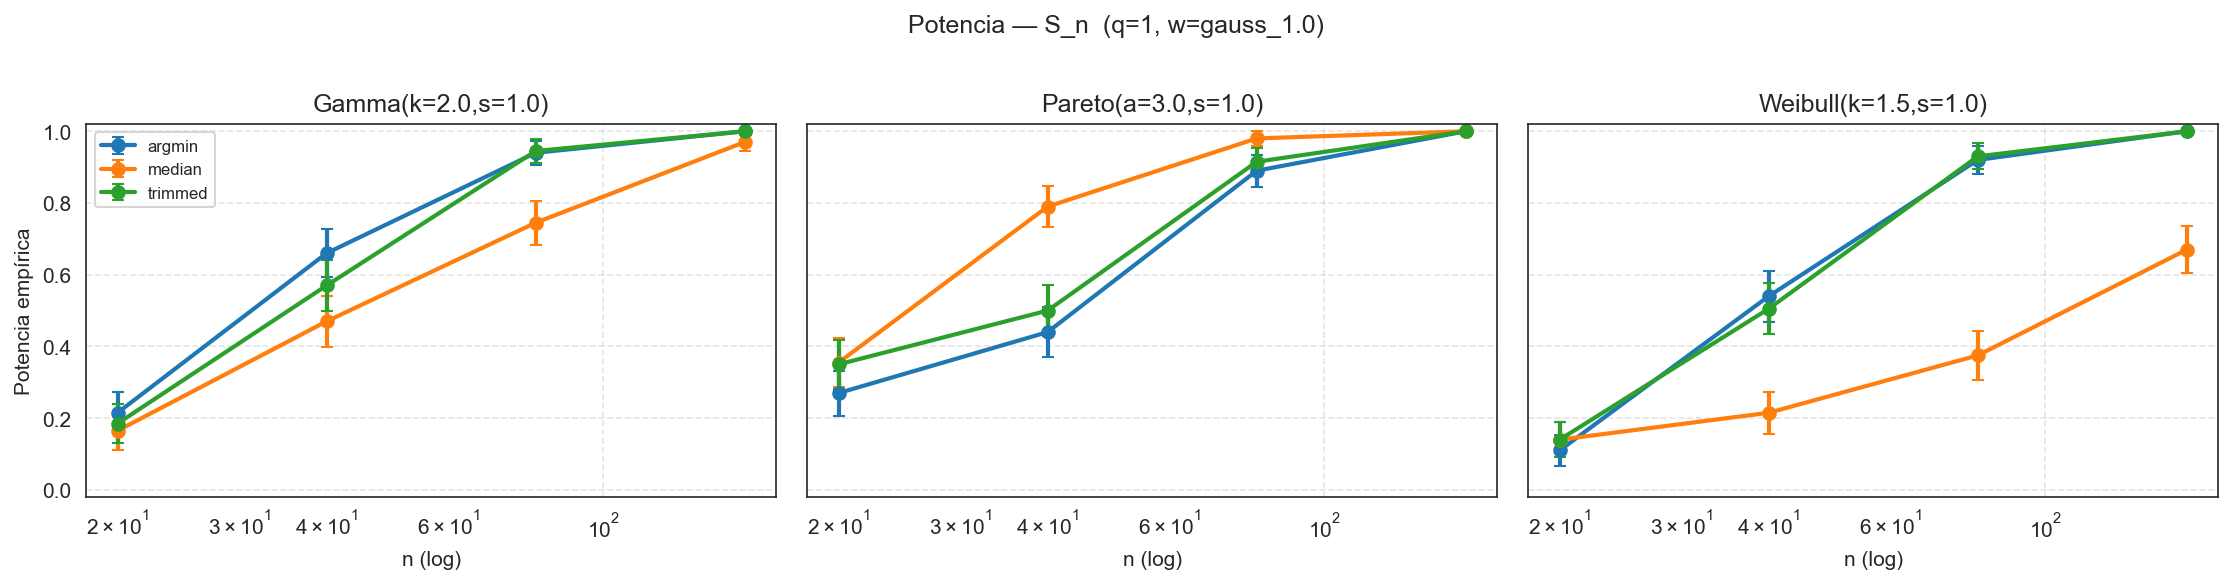

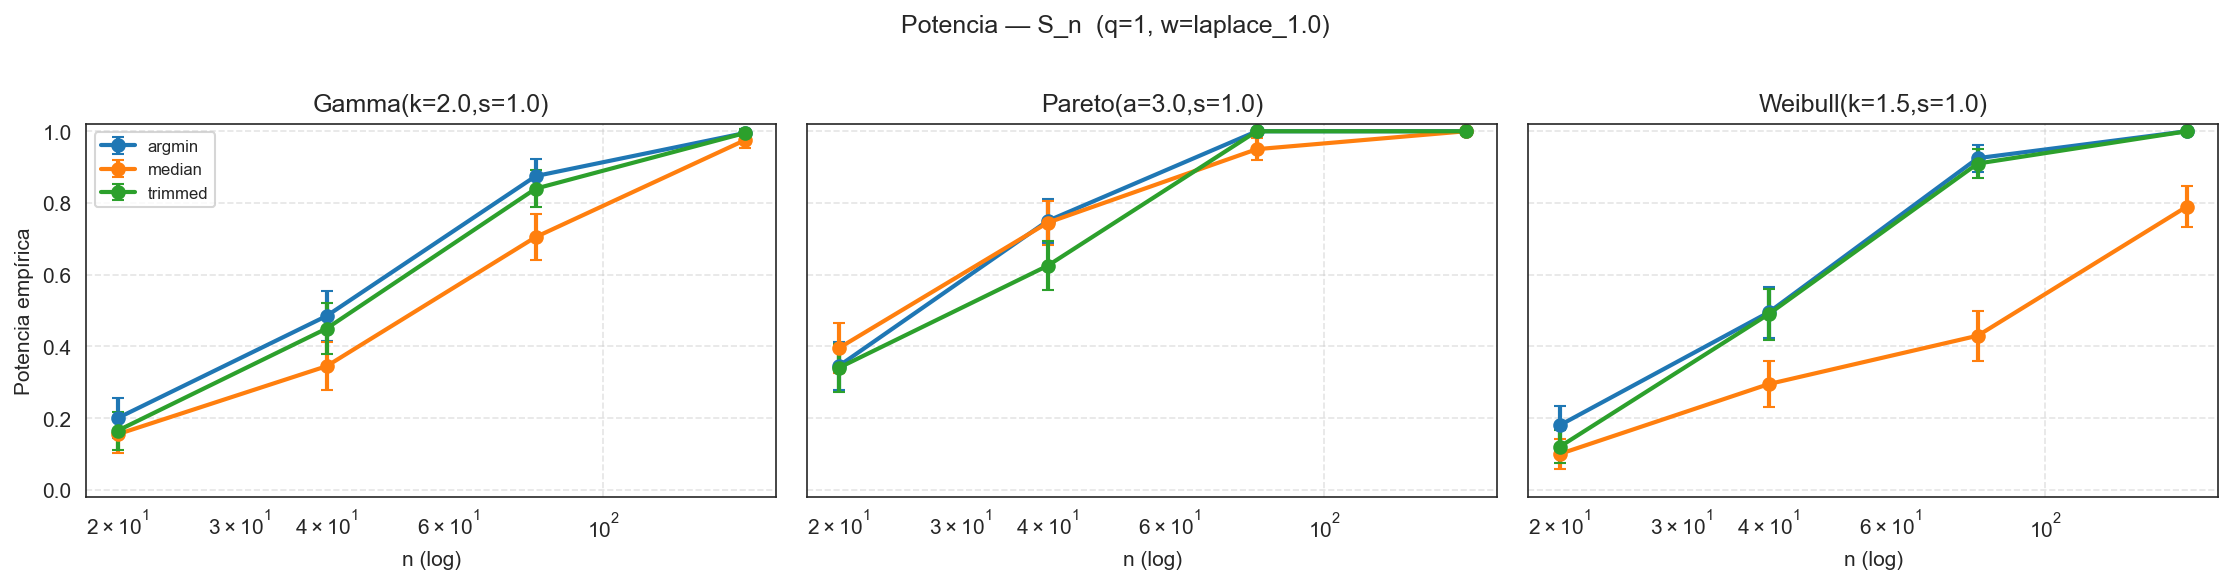

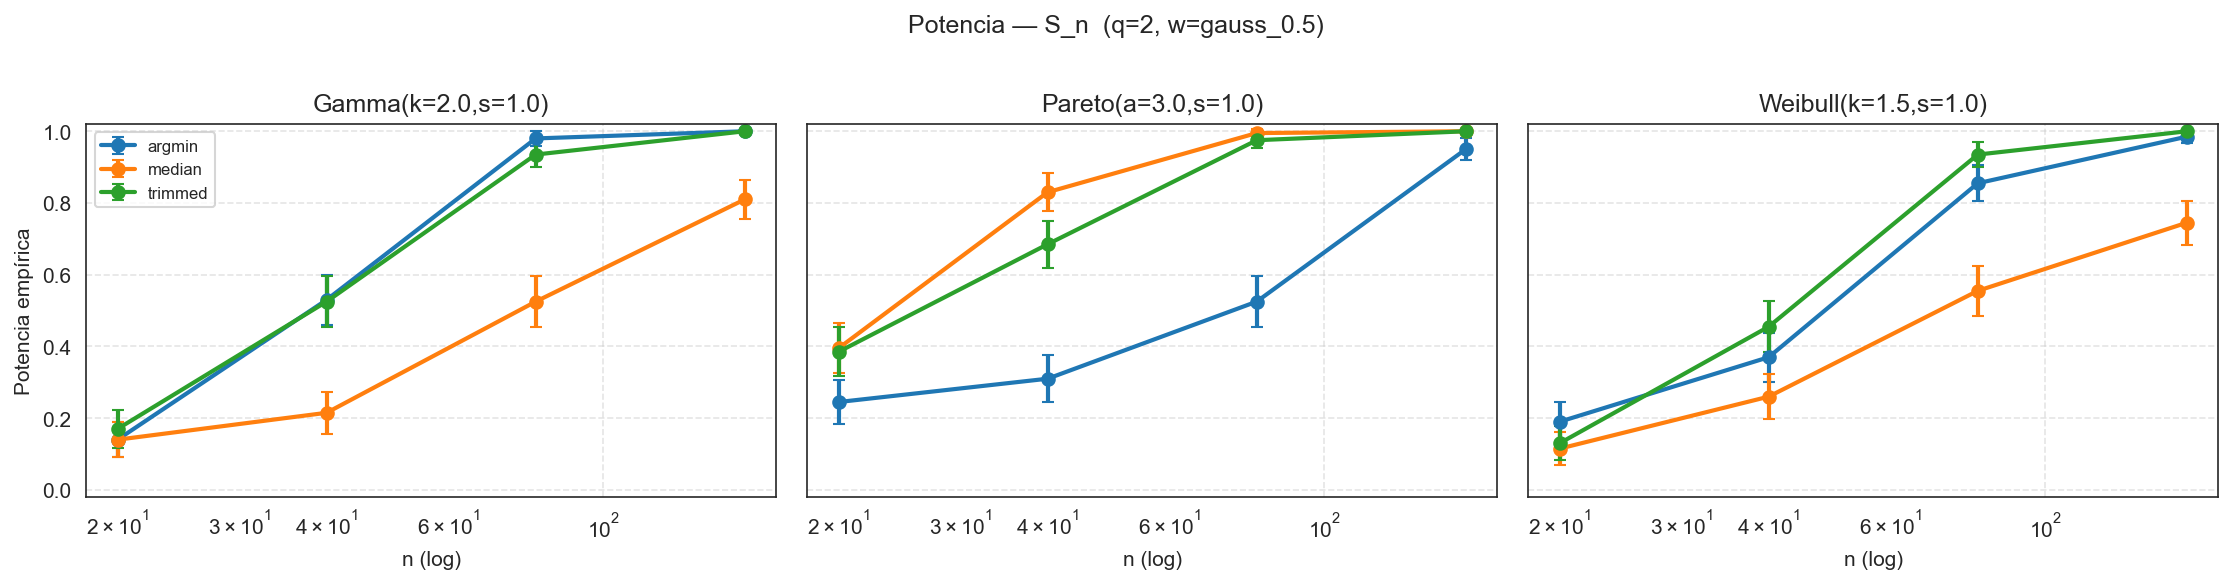

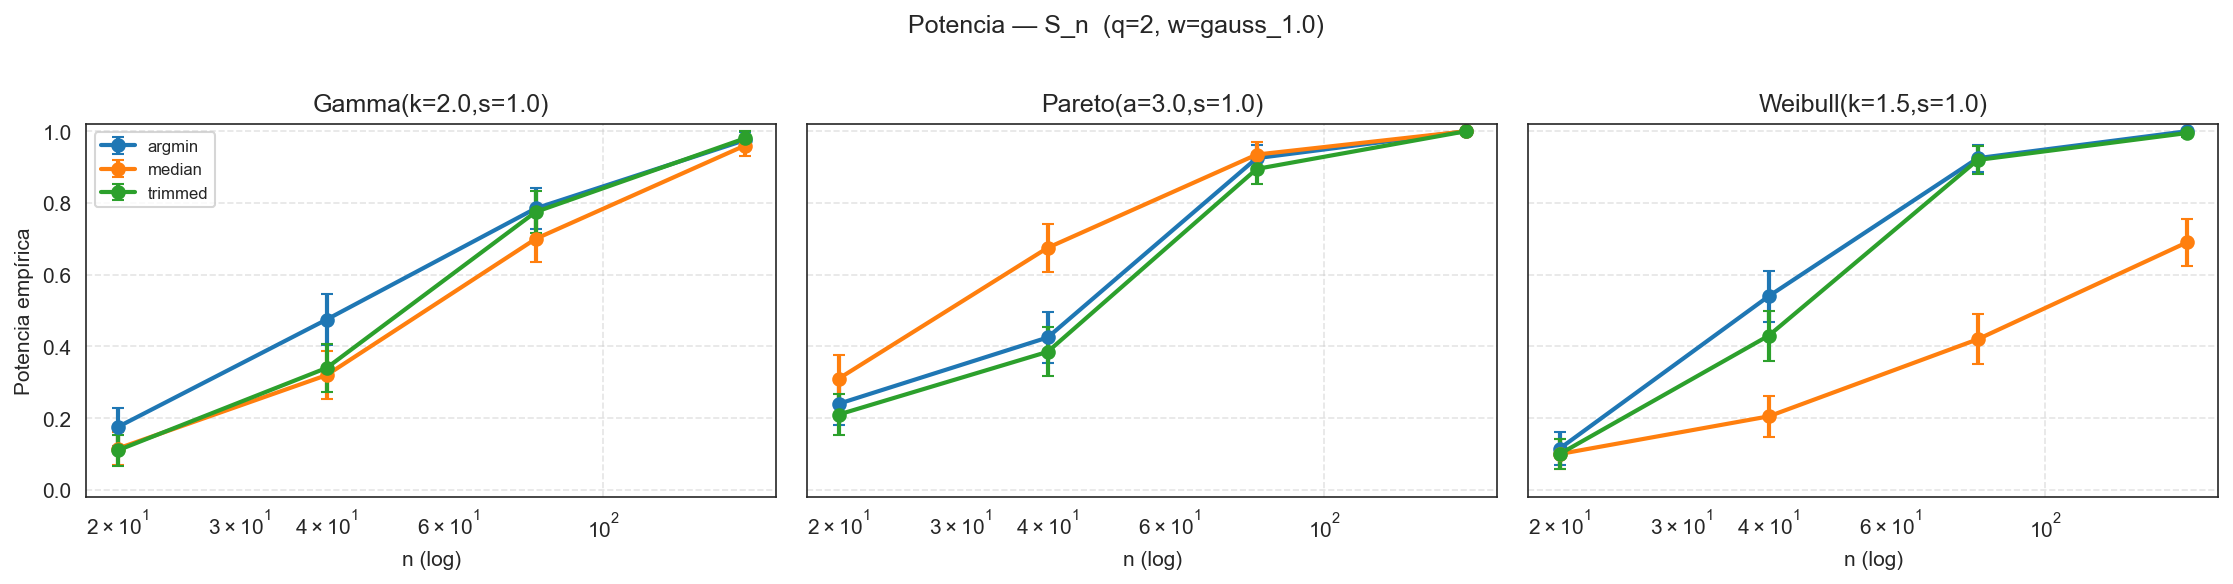

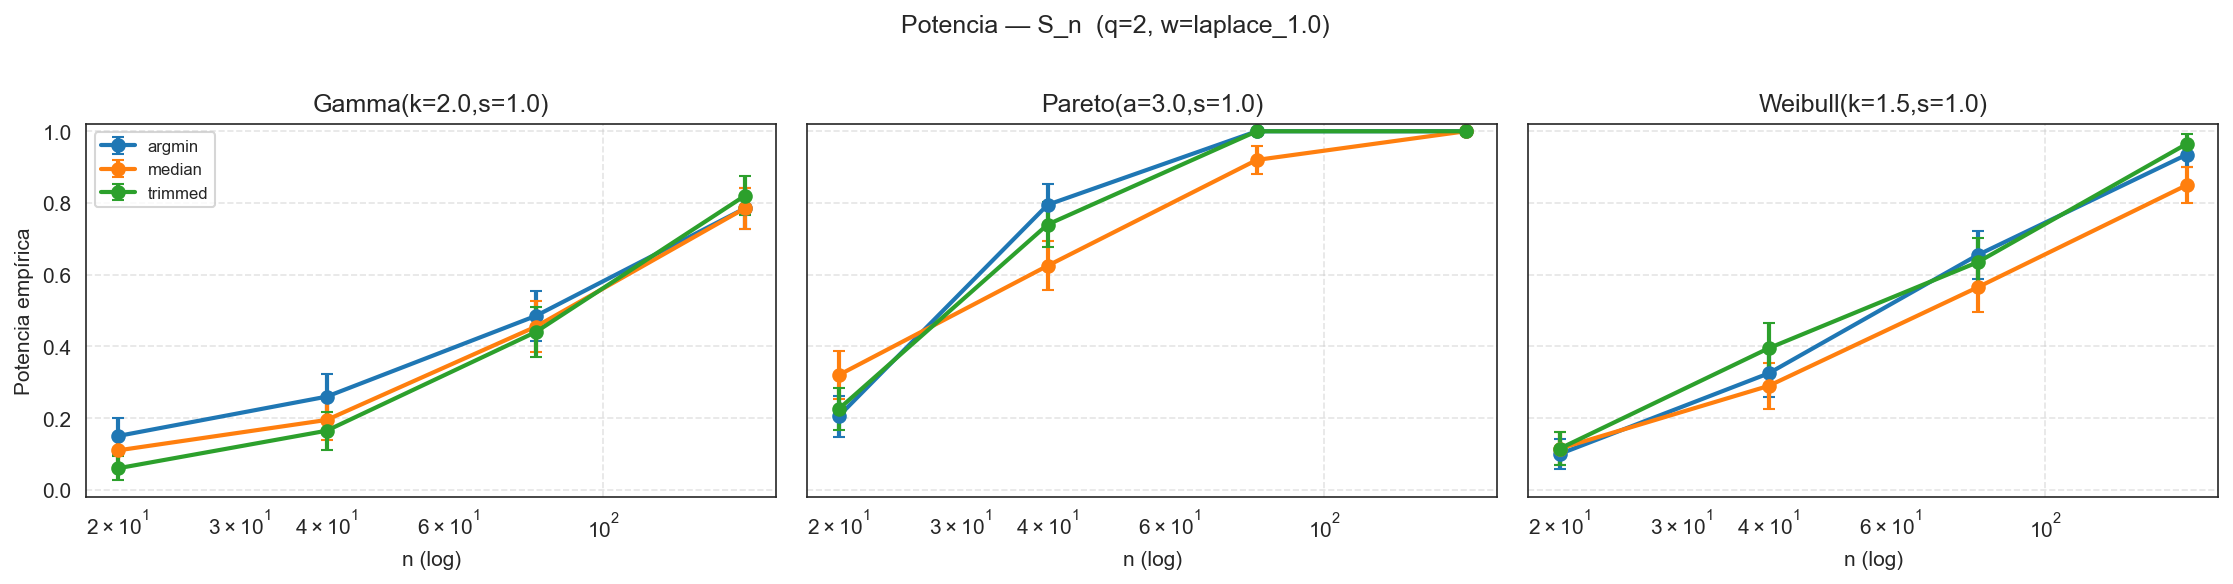

In [28]:
show_many(plot_power_curves_sn(summary_classic, outdir=FIG_DIR))

### Comparacion q=1 vs q=2 (clasico)

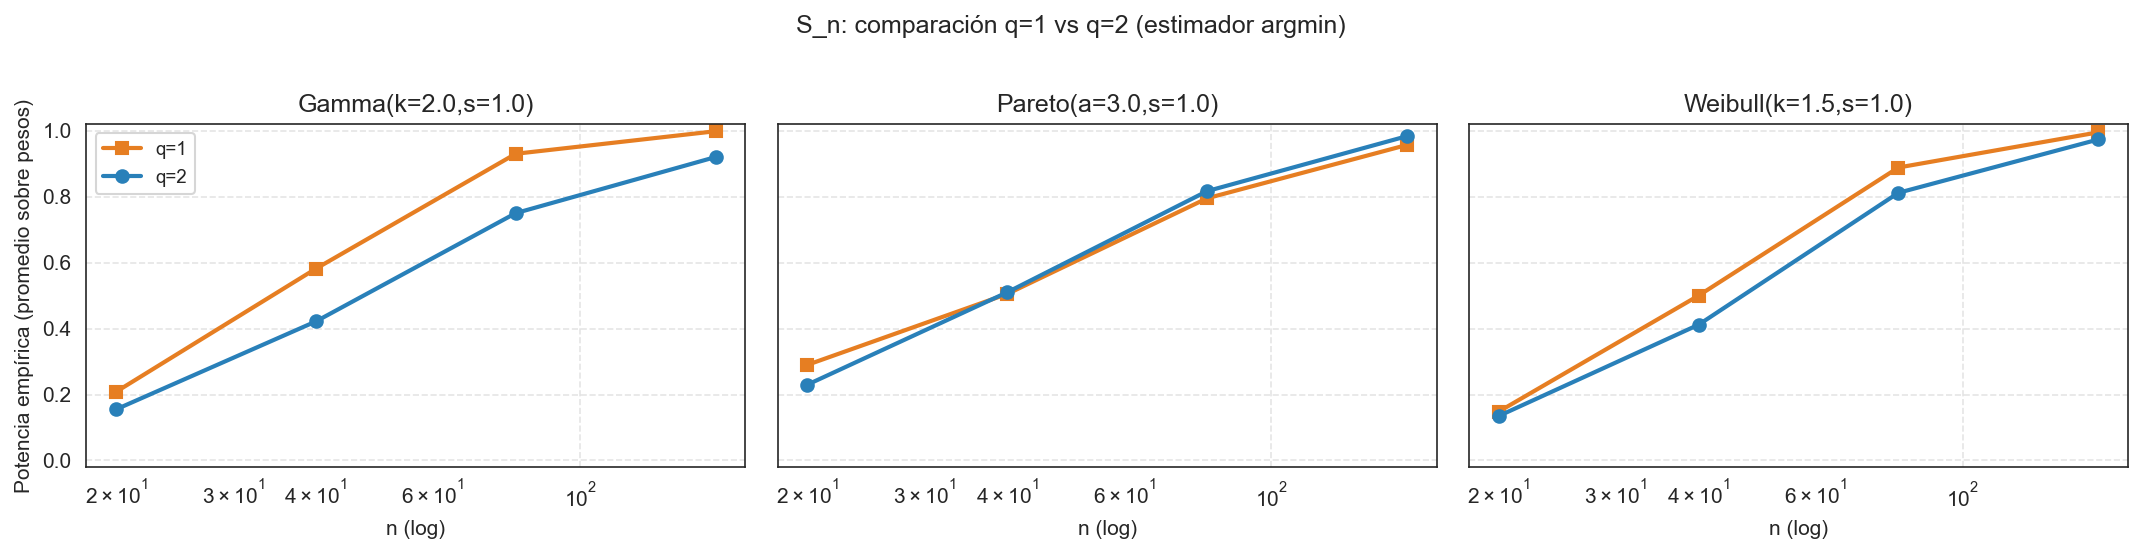

In [29]:
show(plot_q1_vs_q2(summary_classic, outdir=FIG_DIR))

### Comparacion entre funciones de peso $w(t)$ (clasico)

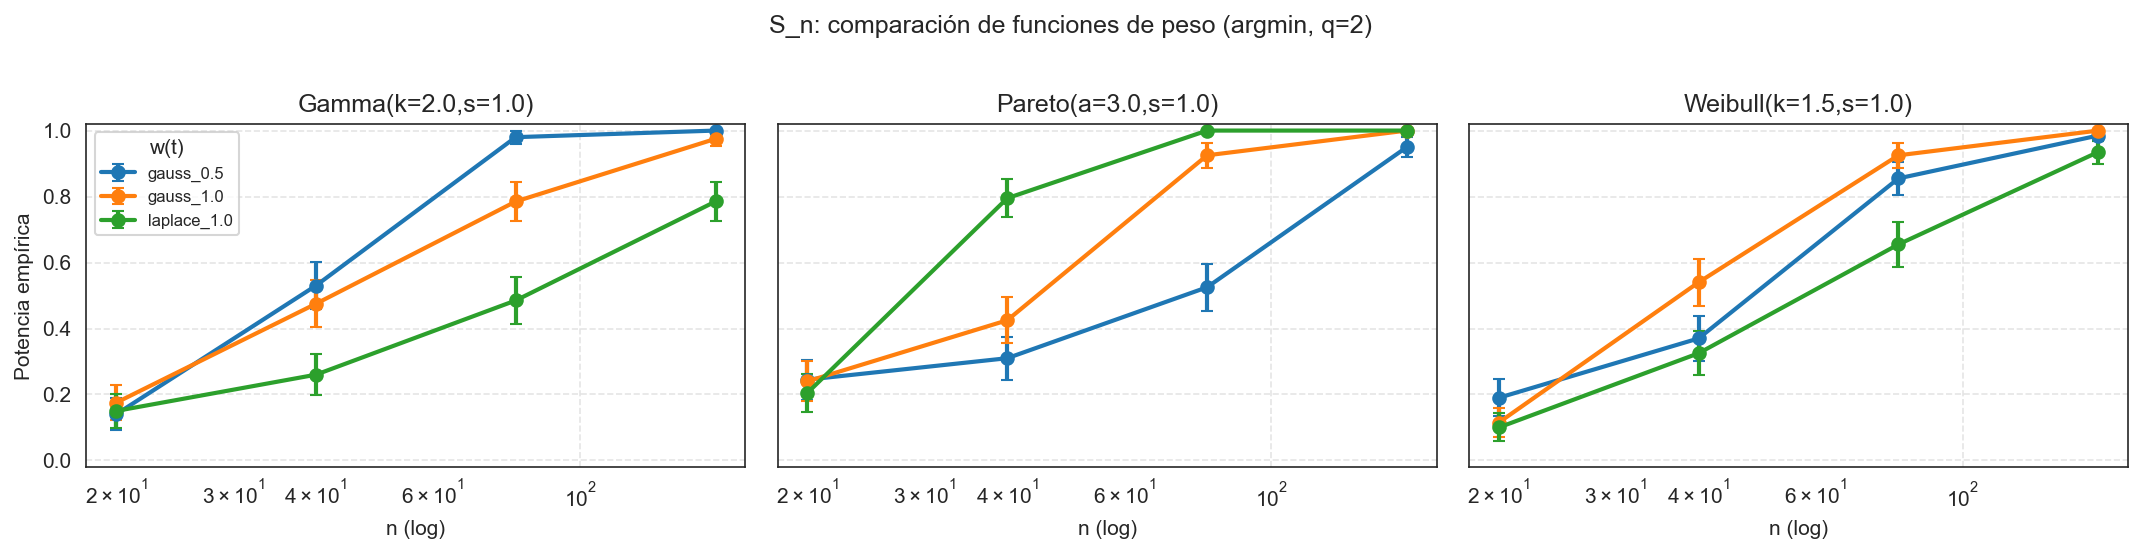

In [30]:
show(plot_weights_compare(summary_classic, outdir=FIG_DIR))

### Heatmap de potencia (clasico, estimador argmin)

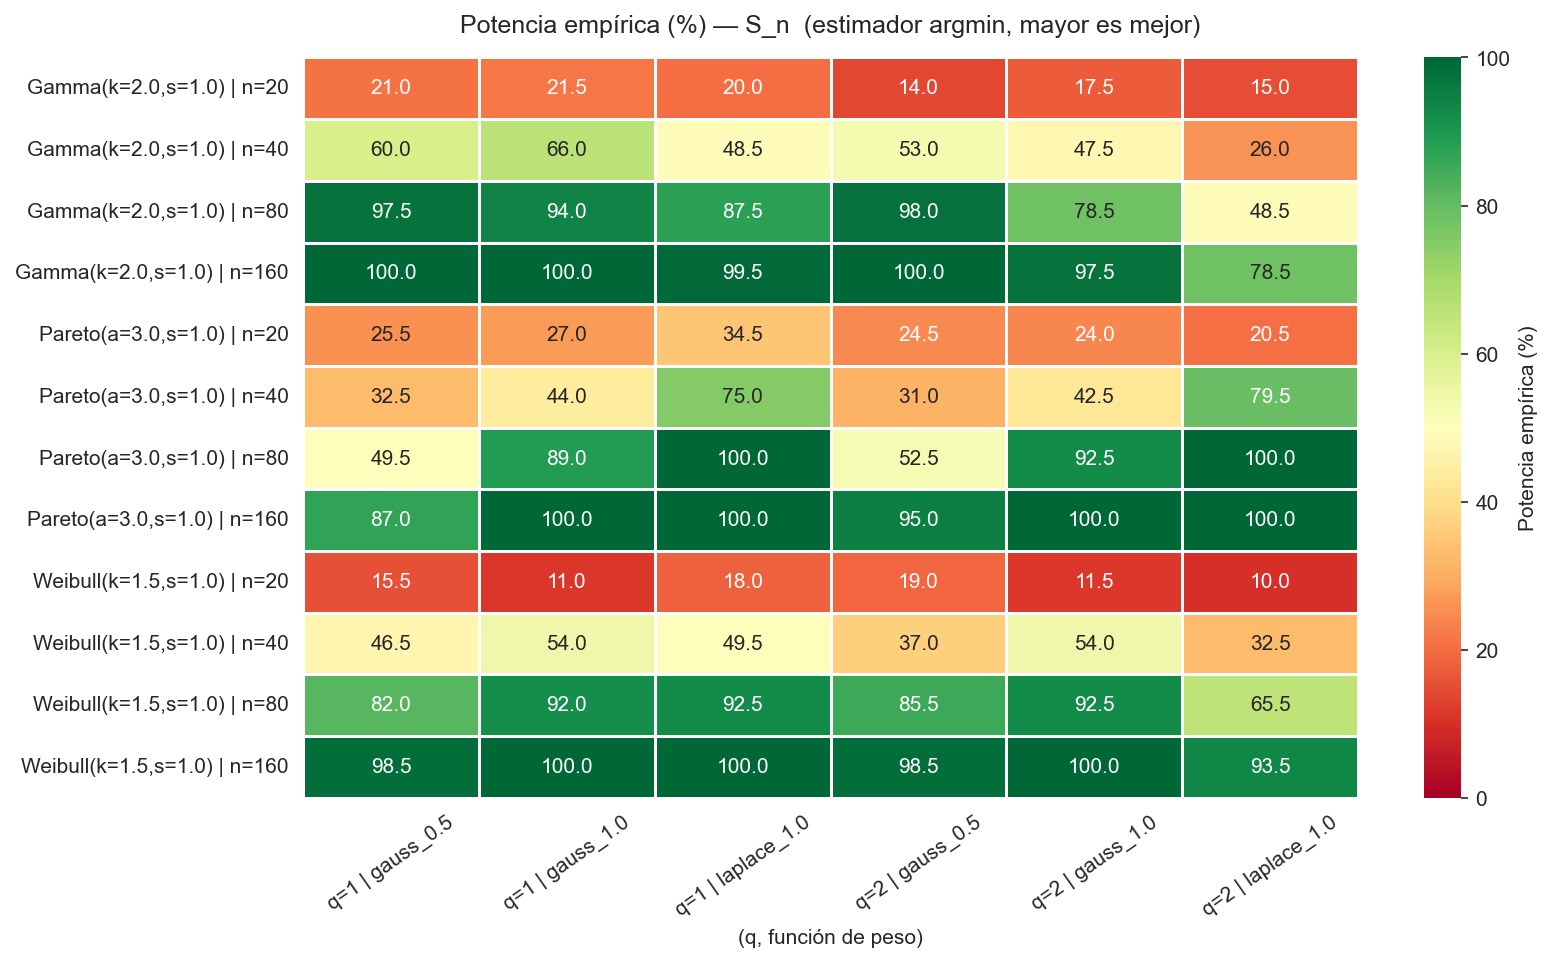

In [31]:
show(plot_power_heatmap(summary_classic, outdir=FIG_DIR))

### Tiempo de ejecucion vs n (clasico)

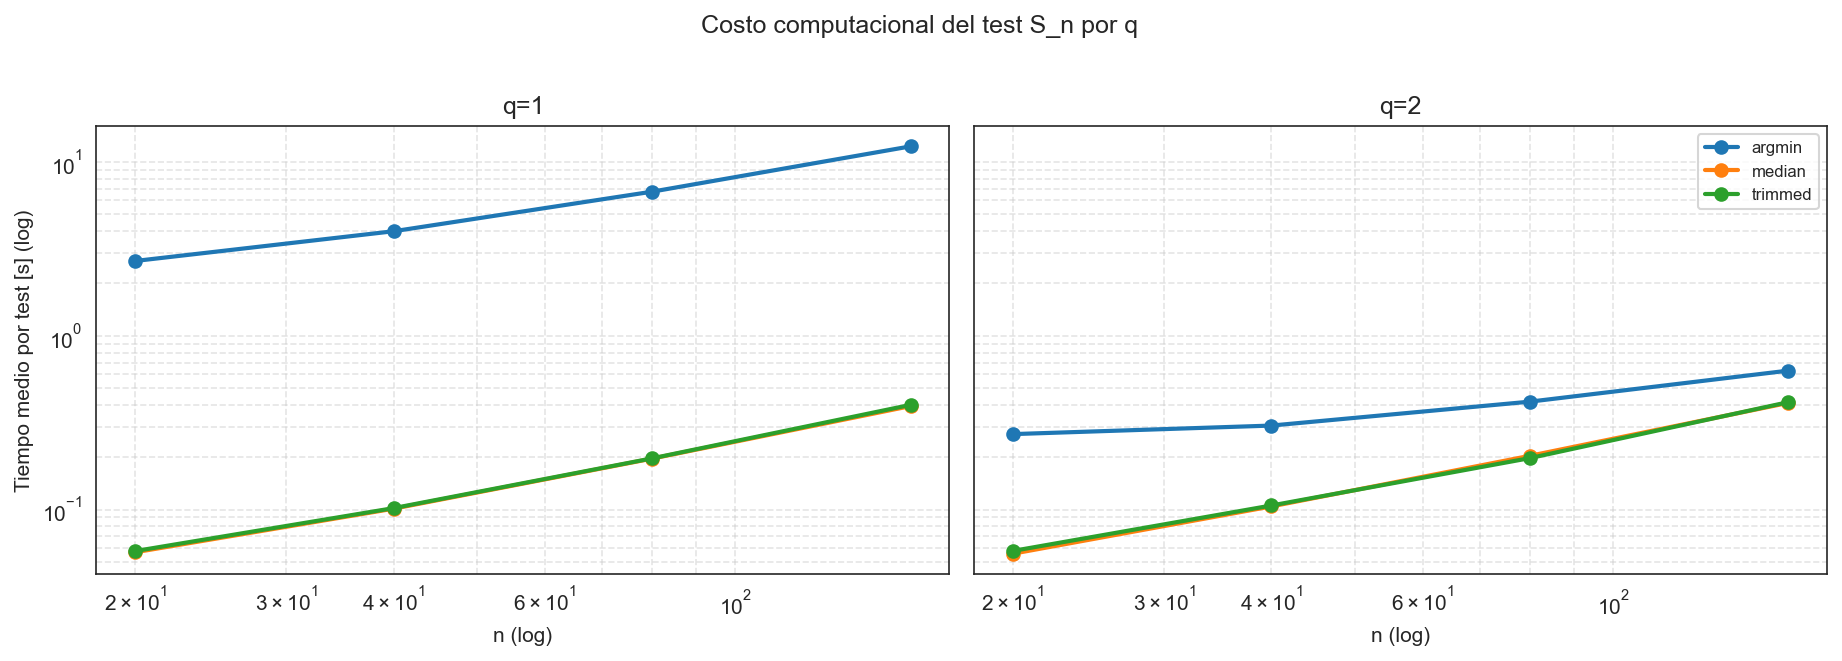

In [32]:
def plot_runtime_sn_by_q(summary, outdir):
    df = summary.copy()
    qs = sorted(df['q'].dropna().unique())
    if not qs:
        return None

    fig, axes = plt.subplots(1, len(qs), figsize=(6.2 * len(qs), 4.3), sharey=True, squeeze=False)
    axes = axes[0]

    for ax, q in zip(axes, qs):
        sub = df[df['q'] == q]
        g = sub.groupby(['n', 'estimator'], as_index=False).agg(mean_time_s=('mean_time_s', 'mean'))
        for est in sorted(g['estimator'].unique()):
            s = g[g['estimator'] == est].sort_values('n')
            ax.plot(s['n'], s['mean_time_s'], marker='o', linewidth=2, label=est)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('n (log)')
        ax.set_title(f'q={q}')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)

    axes[0].set_ylabel('Tiempo medio por test [s] (log)')
    axes[-1].legend(loc='best', fontsize=8)
    fig.suptitle('Costo computacional del test S_n por q', y=1.02)
    fig.tight_layout()
    out = outdir / 'sn_runtime_by_q.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return out

show(plot_runtime_sn_by_q(summary_classic, outdir=FIG_DIR))

### Distribucion del p-valor bajo $H_0$ (clasico)

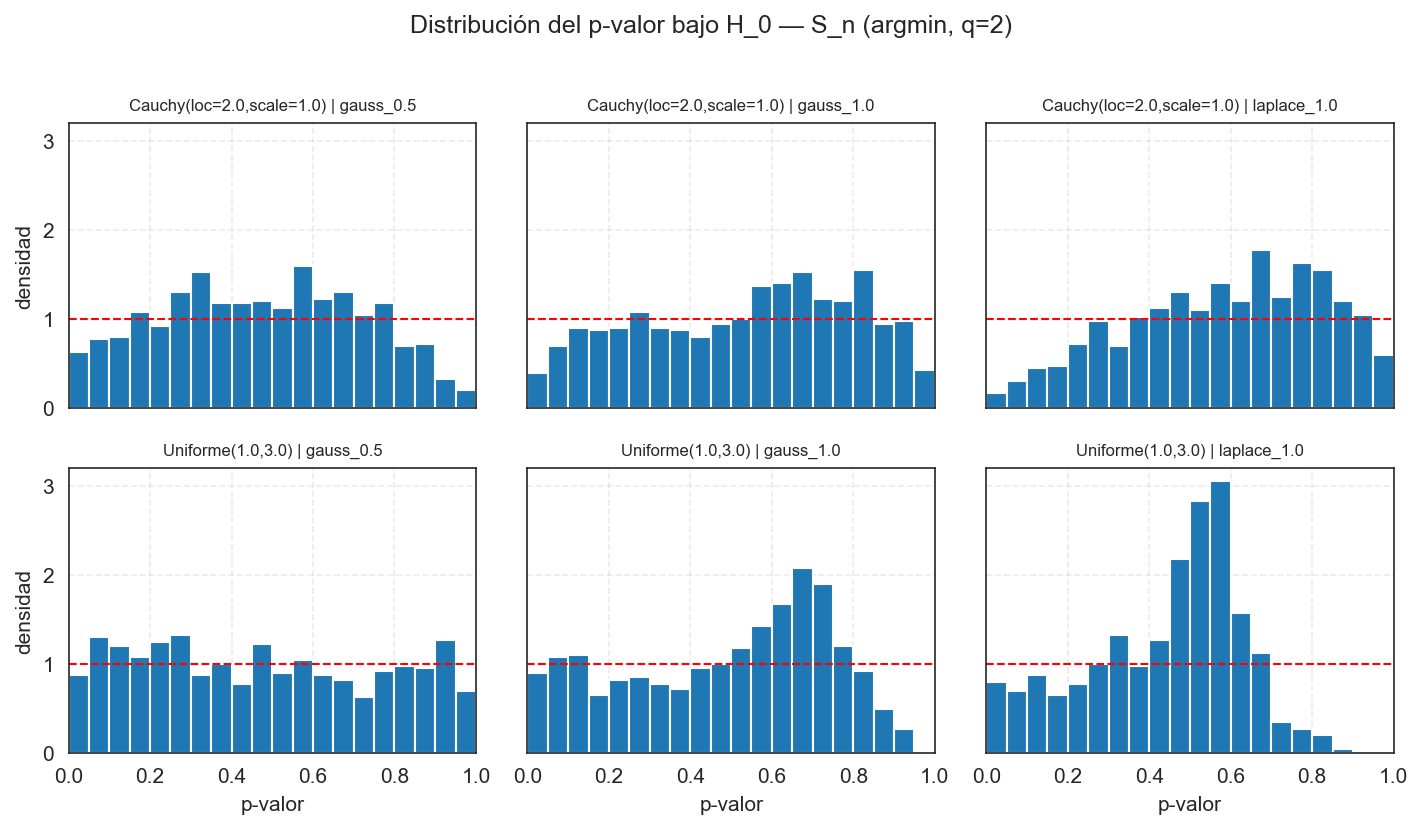

In [33]:
show(plot_pvalue_distribution_h0_sn(df_classic, outdir=FIG_DIR))

## Comparativas $T_n$ vs $S_n$ (clasico)

Potencia:


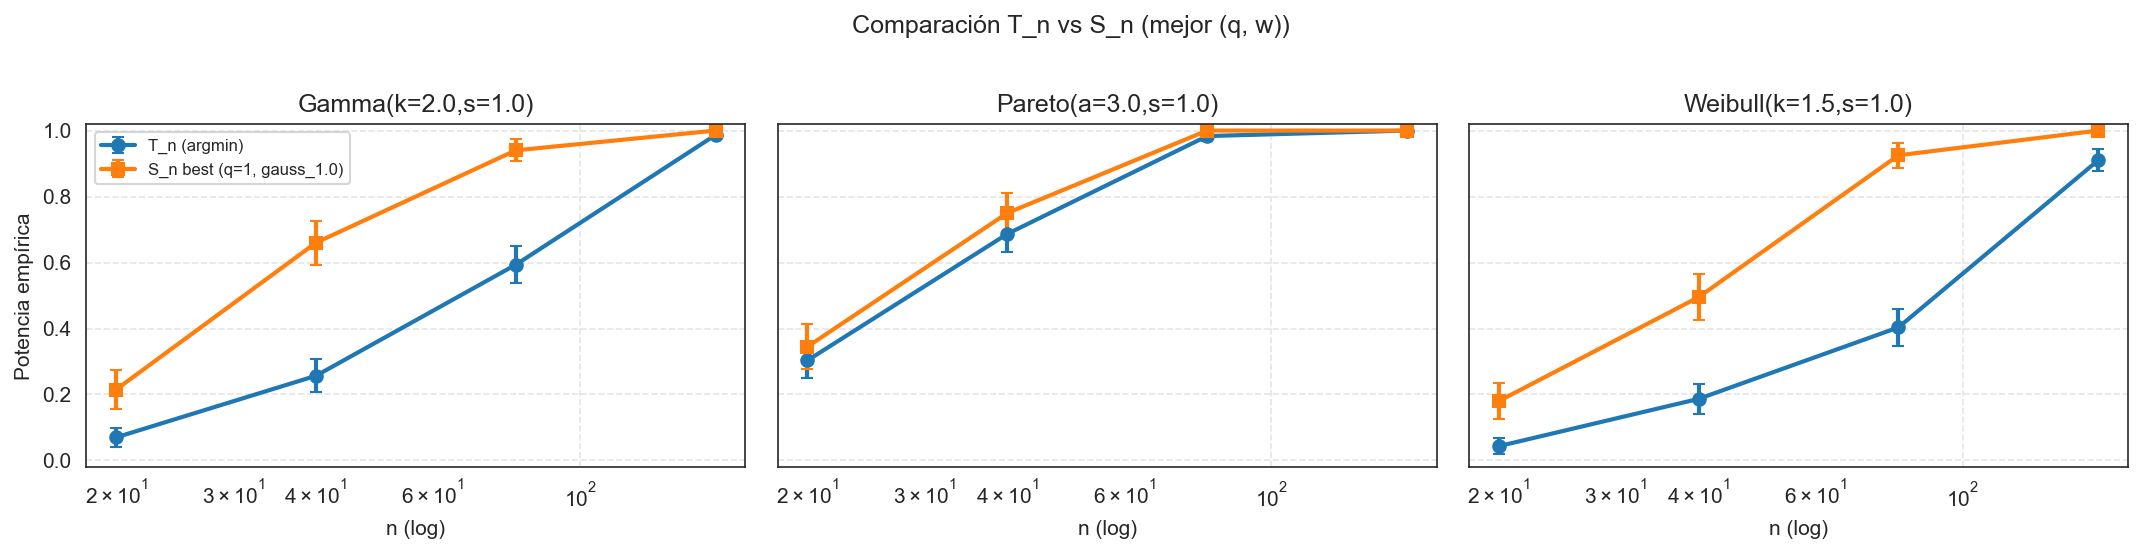

Runtime:


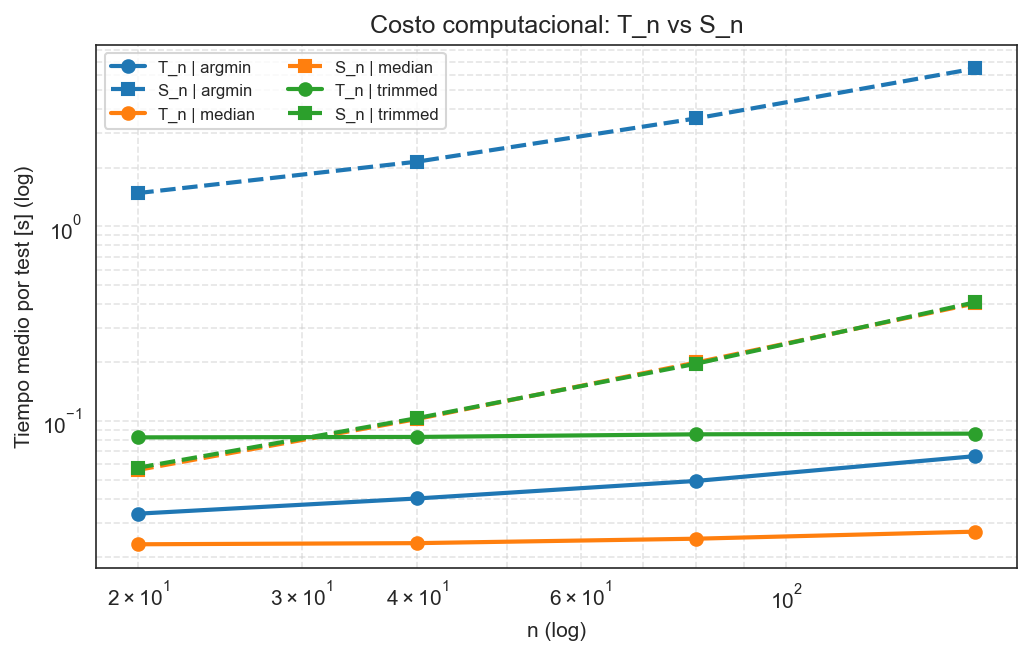

In [34]:
if summary_tn is not None:
    print('Potencia:')
    show(plot_tn_vs_sn_power(summary_tn, summary_classic, outdir=FIG_DIR))
    print('Runtime:')
    show(plot_tn_vs_sn_runtime(summary_tn, summary_classic, outdir=FIG_DIR))
else:
    print('No hay datos de T_n para comparar.')

# Comparativas nuevas: clasico + Pyomo

In [35]:
def _plot_lines_by_dist(data, y_col, title, ylabel, filename, *, hline=None, ylim=None):
    if data.empty:
        print('(sin datos)')
        return None
    dists = sorted(data['dist'].unique())
    n_cols = min(3, len(dists))
    n_rows = int(np.ceil(len(dists) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 3.9 * n_rows), sharey=True, squeeze=False)
    axes_flat = axes.flatten()
    for ax, dist in zip(axes_flat, dists):
        s_dist = data[data['dist'] == dist]
        for cfg in sorted(s_dist['config'].unique()):
            s = s_dist[s_dist['config'] == cfg].sort_values('n')
            yerr = 2 * s['se_rate'] if y_col == 'reject_rate' and 'se_rate' in s else None
            ax.errorbar(s['n'], s[y_col], yerr=yerr, marker='o', capsize=3, linewidth=2, label=cfg)
        if hline is not None:
            ax.axhline(hline, color='black', linestyle='--', linewidth=1)
        ax.set_xscale('log')
        ax.set_xlabel('n (log)')
        ax.set_title(dist)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(True, linestyle='--', alpha=0.45)
    for ax in axes_flat[len(dists):]:
        ax.set_visible(False)
    axes_flat[0].set_ylabel(ylabel)
    axes_flat[0].legend(loc='best', fontsize=7)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return out

def common_support(data, *, q=None, weight='gauss_1.0'):
    out = data[data['weight'].eq(weight)].copy()
    if q is not None:
        out = out[out['q'].eq(q)].copy()
    return out

## Comparacion q=1: estimadores clasicos vs `argmin_pyomo`

Se restringe a `gauss_1.0`, que es el peso disponible en los resultados Pyomo q=1 actuales.

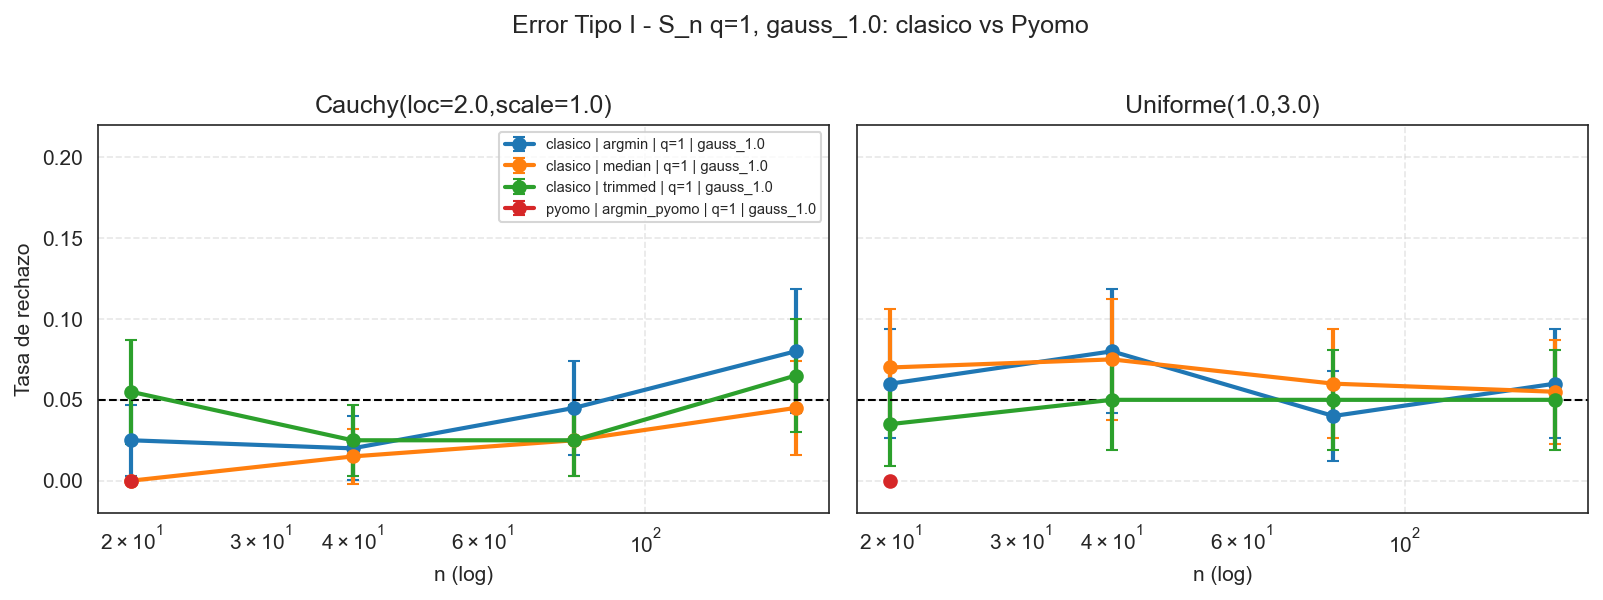

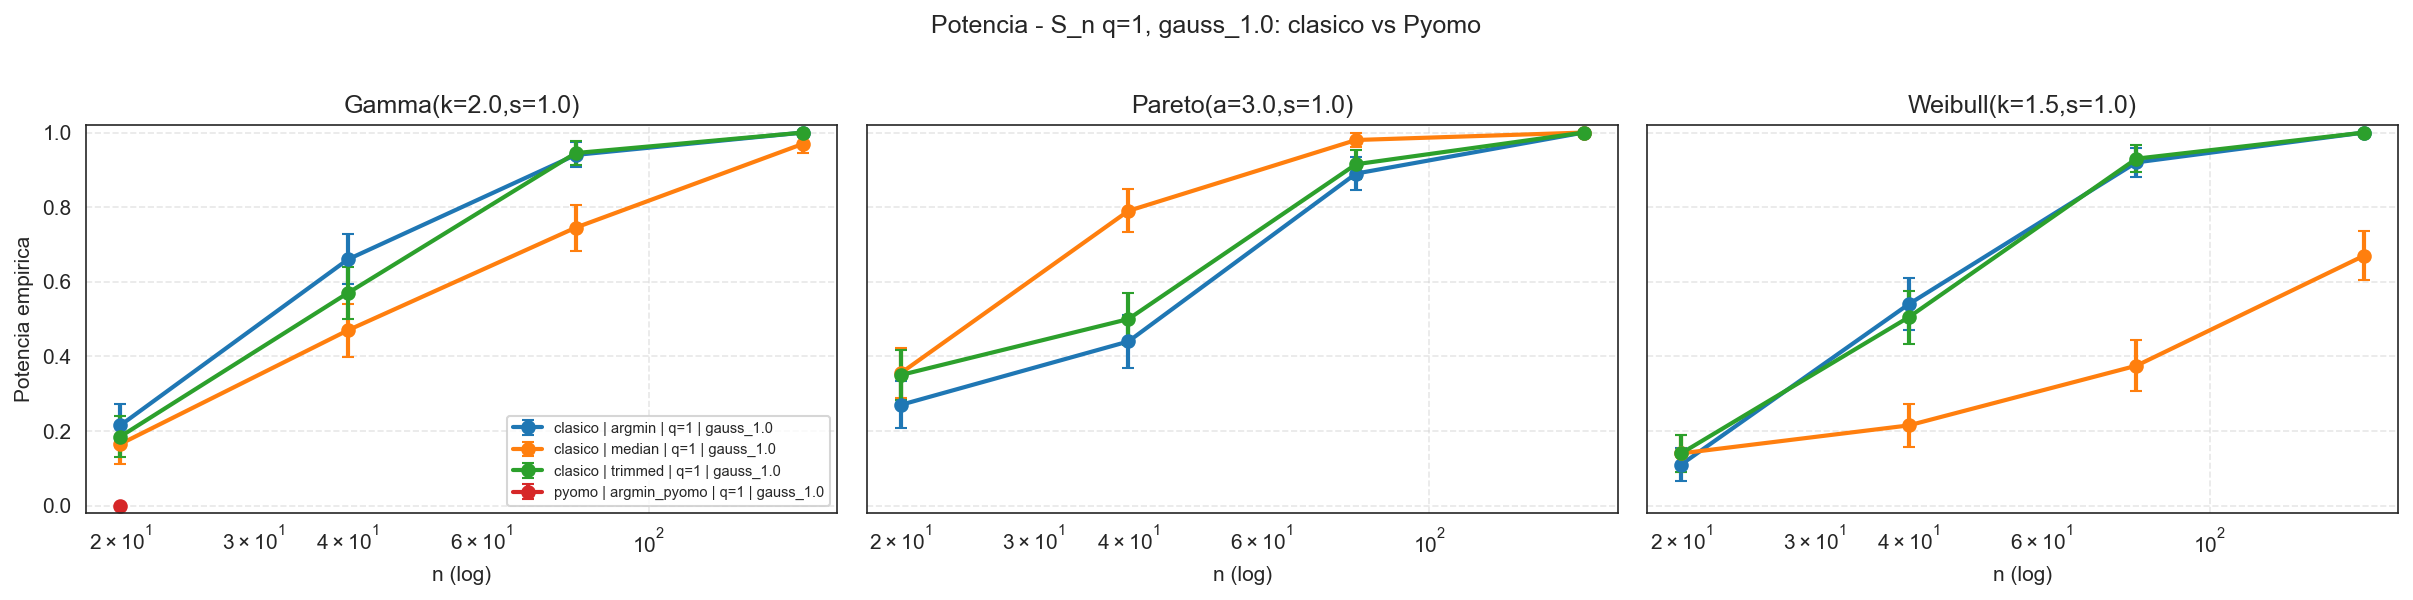

In [36]:
q1_gauss = common_support(summary_all, q=1, weight='gauss_1.0')

show(_plot_lines_by_dist(
    q1_gauss[q1_gauss['under_h0']],
    'reject_rate',
    'Error Tipo I - S_n q=1, gauss_1.0: clasico vs Pyomo',
    'Tasa de rechazo',
    'sn_all_type_i_q1_gauss_pyomo.png',
    hline=alpha,
    ylim=(-0.02, 0.22),
))

show(_plot_lines_by_dist(
    q1_gauss[~q1_gauss['under_h0']],
    'reject_rate',
    'Potencia - S_n q=1, gauss_1.0: clasico vs Pyomo',
    'Potencia empirica',
    'sn_all_power_q1_gauss_pyomo.png',
    ylim=(-0.02, 1.02),
))

## Comparacion Pyomo: q=1 vs q=2

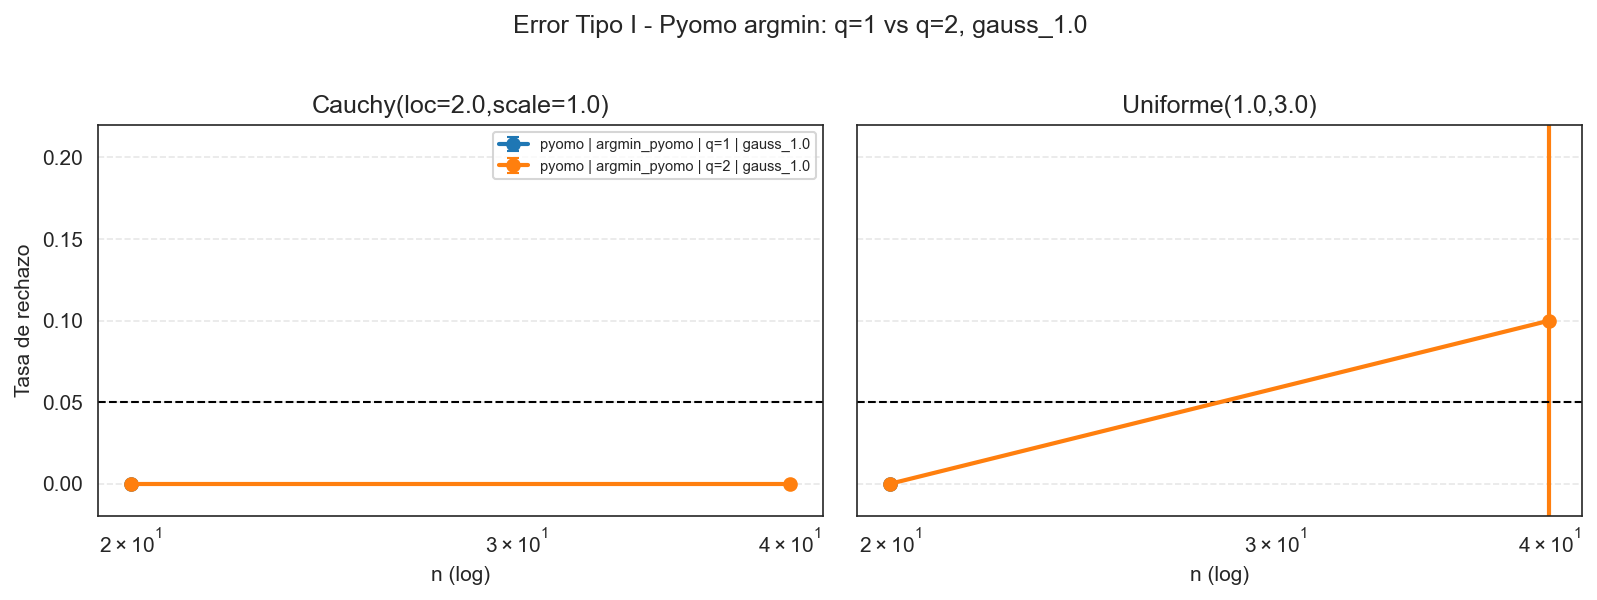

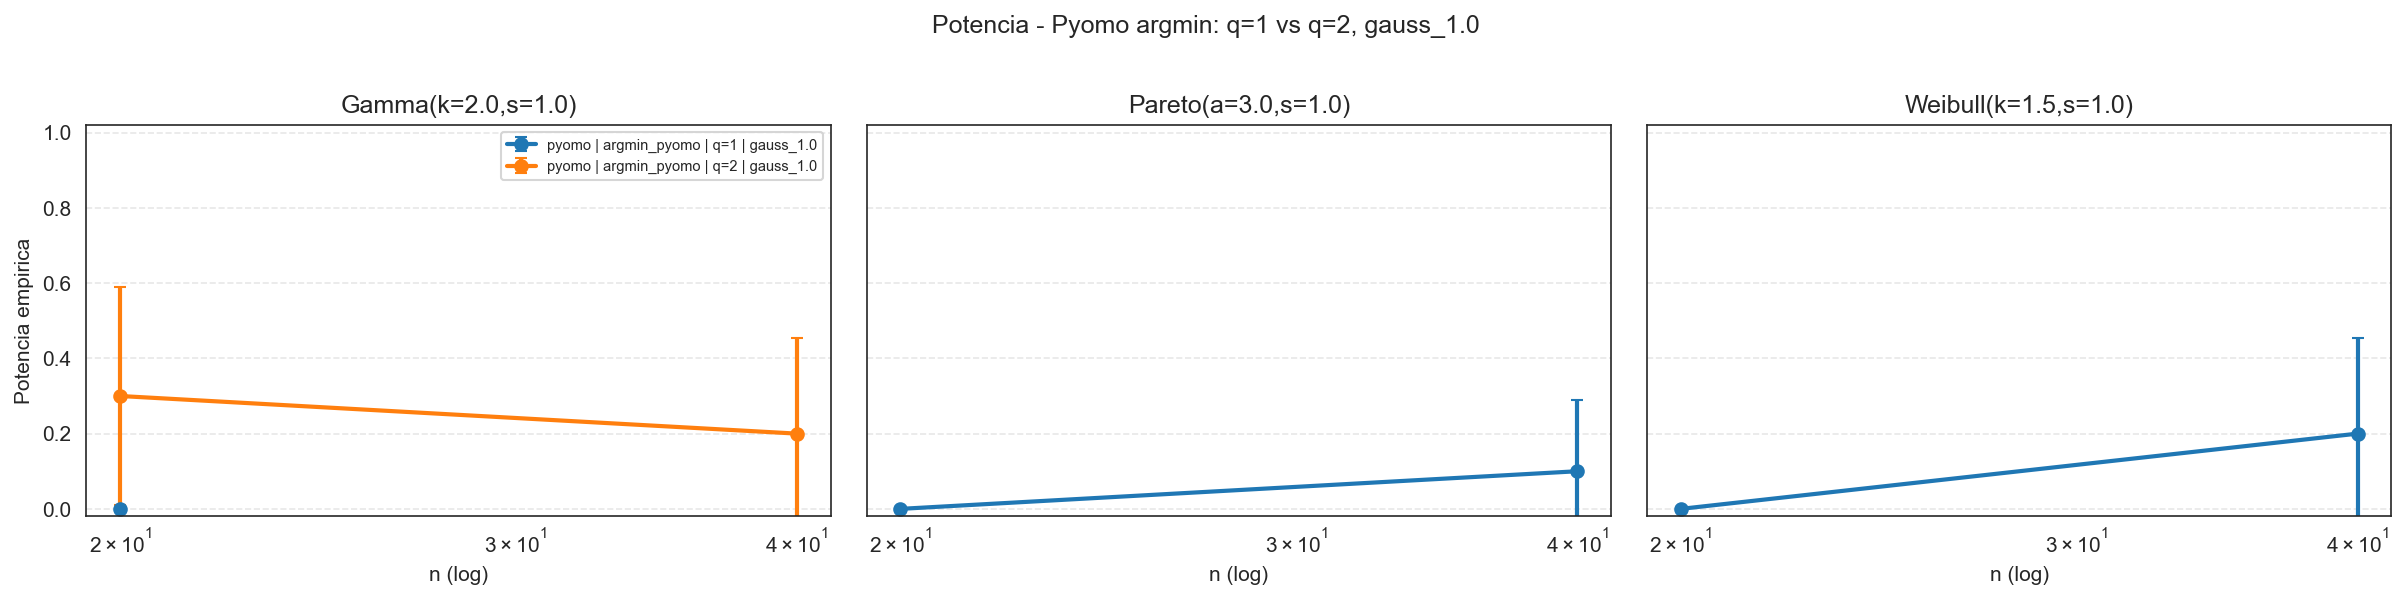

In [37]:
pyomo_gauss = common_support(summary_all[summary_all['source'].eq('pyomo')], weight='gauss_1.0')

show(_plot_lines_by_dist(
    pyomo_gauss[pyomo_gauss['under_h0']],
    'reject_rate',
    'Error Tipo I - Pyomo argmin: q=1 vs q=2, gauss_1.0',
    'Tasa de rechazo',
    'sn_all_pyomo_type_i_q1_vs_q2_gauss.png',
    hline=alpha,
    ylim=(-0.02, 0.22),
))

show(_plot_lines_by_dist(
    pyomo_gauss[~pyomo_gauss['under_h0']],
    'reject_rate',
    'Potencia - Pyomo argmin: q=1 vs q=2, gauss_1.0',
    'Potencia empirica',
    'sn_all_pyomo_power_q1_vs_q2_gauss.png',
    ylim=(-0.02, 1.02),
))

## Heatmap de potencia: todos los metodos en soporte comun q=1

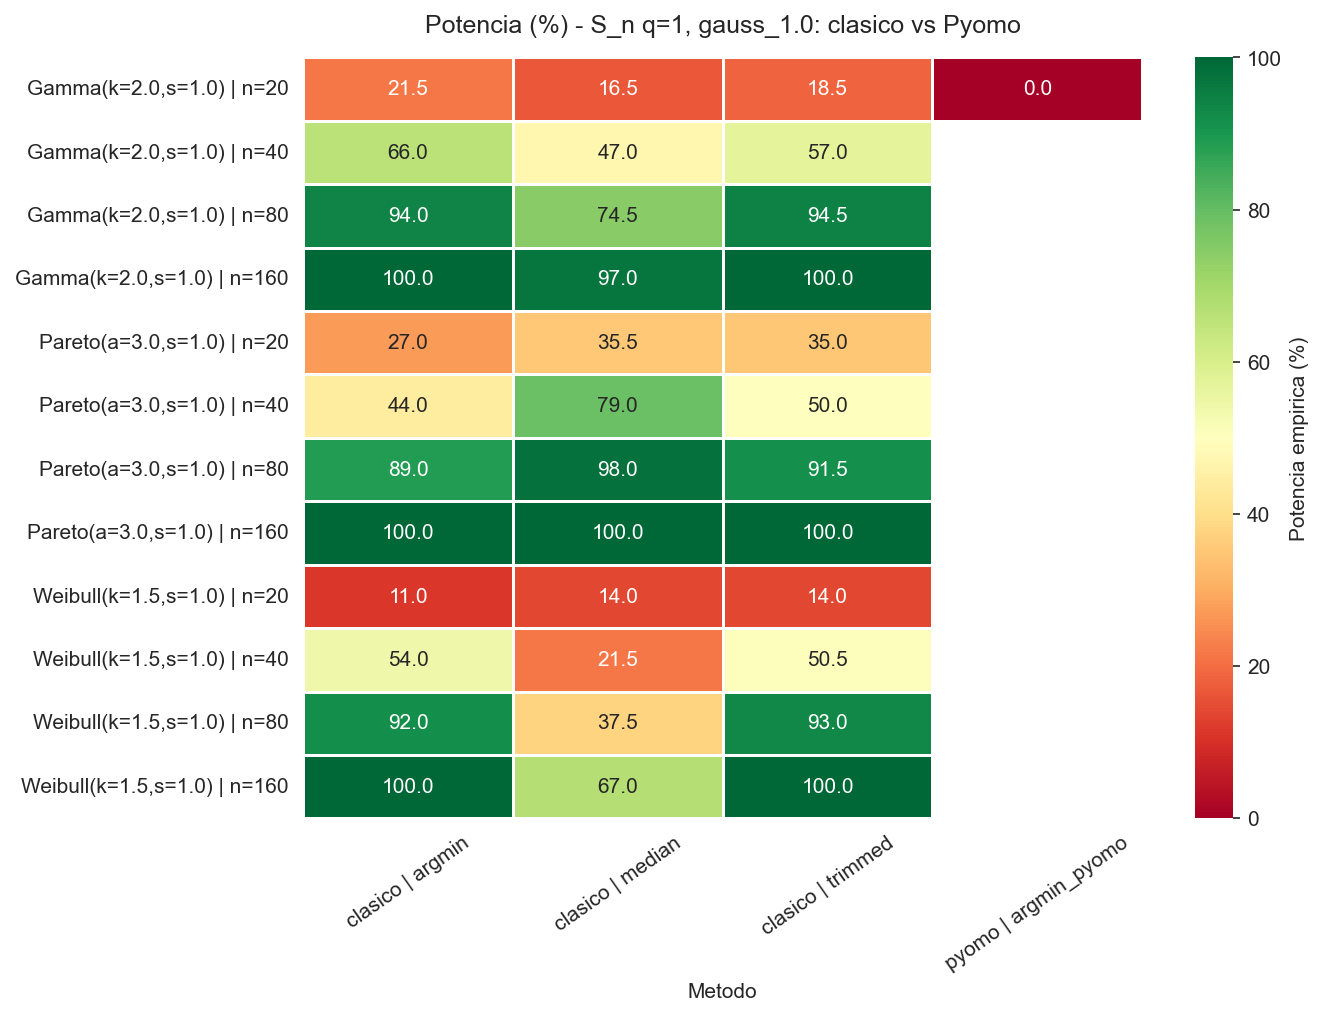

In [38]:
heat = q1_gauss[~q1_gauss['under_h0']].copy()
if heat.empty:
    print('(sin datos)')
else:
    heat['col'] = heat['method']
    pivot = heat.pivot_table(index=['dist', 'n'], columns='col', values='reject_rate') * 100
    pivot.index = [f'{d} | n={n}' for d, n in pivot.index]
    fig, ax = plt.subplots(figsize=(max(8, 1.8 * len(pivot.columns) + 2), max(4.5, 0.45 * len(pivot.index) + 1.5)))
    import seaborn as sns
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.5, linecolor='white', cbar_kws={'label': 'Potencia empirica (%)'}, ax=ax)
    ax.set_title('Potencia (%) - S_n q=1, gauss_1.0: clasico vs Pyomo', pad=12)
    ax.set_xlabel('Metodo')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)
    fig.tight_layout()
    out = FIG_DIR / 'sn_all_power_heatmap_q1_gauss_pyomo.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.close(fig)
    show(out)

## Runtime: todos los metodos

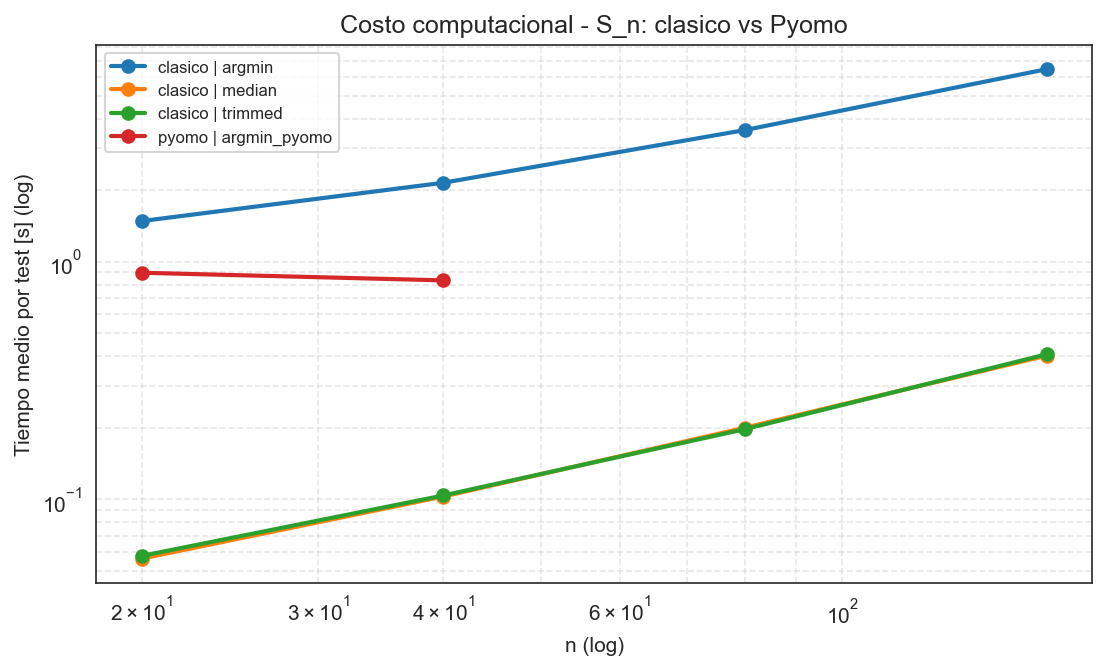

In [39]:
runtime = summary_all.copy()
runtime_g = runtime.groupby(['n', 'method'], as_index=False).agg(mean_time_s=('mean_time_s', 'mean'))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for method in sorted(runtime_g['method'].unique()):
    s = runtime_g[runtime_g['method'] == method].sort_values('n')
    ax.plot(s['n'], s['mean_time_s'], marker='o', linewidth=2, label=method)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('n (log)')
ax.set_ylabel('Tiempo medio por test [s] (log)')
ax.set_title('Costo computacional - S_n: clasico vs Pyomo')
ax.grid(True, which='both', linestyle='--', alpha=0.45)
ax.legend(fontsize=8)
fig.tight_layout()
runtime_out = FIG_DIR / 'sn_all_runtime_classic_vs_pyomo.png'
fig.savefig(runtime_out, dpi=150, bbox_inches='tight')
plt.close(fig)
show(runtime_out)

## Tabla comparativa final

Esta tabla deja juntas las tasas de rechazo en el soporte comun `q=1`, `gauss_1.0`.

In [40]:
compare_table = q1_gauss.pivot_table(
    index=['dist', 'under_h0', 'n'],
    columns='method',
    values='reject_rate',
)
display(compare_table.round(3))

print('Archivos nuevos esperados con prefijo sn_all_:')
for path in sorted(FIG_DIR.glob('sn_all_*.png')):
    print(f'  {path.name}')

method                                  clasico | argmin  clasico | median  \
dist                      under_h0 n                                         
Cauchy(loc=2.0,scale=1.0) True     20              0.025             0.000   
                                   40              0.020             0.015   
                                   80              0.045             0.025   
                                   160             0.080             0.045   
Gamma(k=2.0,s=1.0)        False    20              0.215             0.165   
                                   40              0.660             0.470   
                                   80              0.940             0.745   
                                   160             1.000             0.970   
Pareto(a=3.0,s=1.0)       False    20              0.270             0.355   
                                   40              0.440             0.790   
                                   80              0.890             0.980   
                                   160             1.000             1.000   
Uniforme(1.0,3.0)         True     20              0.060             0.070   
                                   40              0.080             0.075   
                                   80              0.040             0.060   
                                   160             0.060             0.055   
Weibull(k=1.5,s=1.0)      False    20              0.110             0.140   
                                   40              0.540             0.215   
                                   80              0.920             0.375   
                                   160             1.000             0.670   

method                                  clasico | trimmed  \
dist                      under_h0 n                        
Cauchy(loc=2.0,scale=1.0) True     20               0.055   
                                   40               0.025   
                                   80               0.025   
                                   160              0.065   
Gamma(k=2.0,s=1.0)        False    20               0.185   
                                   40               0.570   
                                   80               0.945   
                                   160              1.000   
Pareto(a=3.0,s=1.0)       False    20               0.350   
                                   40               0.500   
                                   80               0.915   
                                   160              1.000   
Uniforme(1.0,3.0)         True     20               0.035   
                                   40               0.050   
                                   80               0.050   
                                   160              0.050   
Weibull(k=1.5,s=1.0)      False    20               0.140   
                                   40               0.505   
                                   80               0.930   
                                   160              1.000   

method                                  pyomo | argmin_pyomo  
dist                      under_h0 n                          
Cauchy(loc=2.0,scale=1.0) True     20                    0.0  
                                   40                    NaN  
                                   80                    NaN  
                                   160                   NaN  
Gamma(k=2.0,s=1.0)        False    20                    0.0  
                                   40                    NaN  
                                   80                    NaN  
                                   160                   NaN  
Pareto(a=3.0,s=1.0)       False    20                    NaN  
                                   40                    NaN  
                                   80                    NaN  
                                   160                   NaN  
Uniforme(1.0,3.0)         True     20                    0

Archivos nuevos esperados con prefijo sn_all_:
  sn_all_power_heatmap_q1_gauss_pyomo.png
  sn_all_power_q1_gauss_pyomo.png
  sn_all_pyomo_power_q1_vs_q2_gauss.png
  sn_all_pyomo_type_i_q1_vs_q2_gauss.png
  sn_all_runtime_classic_vs_pyomo.png
  sn_all_type_i_q1_gauss_pyomo.png
